# Crypto EDA — Phân tích Top 10 đồng Coin
**Môn học:** Phân tích dữ liệu sử dụng Python  
**Nguồn dữ liệu chính:** Binance API (OHLCV lịch sử)  
**Timeframe:** Theo ngày (1D) | Giai đoạn: 01/01/2020 - 31/12/2024

> **Ghi chú phạm vi dữ liệu:**
> - Dữ liệu OHLCV được giới hạn trong giai đoạn 01/01/2020 - 31/12/2024.
> - Các coin niêm yết sau 01/01/2020 (SOL, DOT, AVAX) chỉ được phân tích từ ngày có dữ liệu thực tế.
> - Không sử dụng dữ liệu nằm ngoài giai đoạn nghiên cứu để đưa ra kết luận chính.

---

## Mục lục
1. [Cài đặt & Import thư viện](#sec1)
2. [Thu thập dữ liệu](#sec2)
3. [Kiểm tra chất lượng & Làm sạch](#sec3)
4. [Phân tích giá & xu hướng](#sec4)
5. [Phân tích biến động (Volatility)](#sec5)
6. [Phân tích tương quan (Correlation)](#sec6)
7. [Phân tích Volume & Trades](#sec7)
8. [Phân tích OHLC & ATH](#sec8)
9. [Kết luận & Insight](#sec9)


## Mục tiêu và câu hỏi phân tích

**Mục tiêu:** phân tích dữ liệu giao dịch hằng ngày của 10 đồng crypto trong giai đoạn 01/01/2020 - 31/12/2024 để nhận diện xu hướng giá, mức độ biến động, mối quan hệ với BTC và vai trò của thanh khoản.

**Câu hỏi phân tích chính:**
1. Coin nào tăng trưởng tốt nhất và kém nhất trong giai đoạn 2020-2024?
2. Coin nào có biến động giá lớn nhất, thể hiện rủi ro cao hơn?
3. Daily return của các altcoin có tương quan với BTC đến mức nào?
4. Volume giao dịch có đi kèm các ngày biến động giá mạnh hay không?
5. Việc một số coin niêm yết sau 01/01/2020 ảnh hưởng thế nào đến so sánh kết quả?

**Ý nghĩa:** phần này xác định rõ các câu hỏi cần trả lời, giúp mỗi bước xử lý và trực quan hóa đều gắn với một mục đích phân tích cụ thể.

---

## Data Dictionary

| Trường dữ liệu | Ý nghĩa | Vai trò trong phân tích |
|---|---|---|
| date | Ngày giao dịch theo khung 1D | Mốc thời gian để lọc đúng giai đoạn 2020-2024 |
| open | Giá mở cửa trong ngày | Dùng cho phân tích OHLC/candlestick |
| high | Giá cao nhất trong ngày | Dùng để tính ATH trong giai đoạn nghiên cứu |
| low | Giá thấp nhất trong ngày | Dùng để tính biên độ dao động trong ngày |
| close | Giá đóng cửa trong ngày | Biến chính để tính return, xu hướng và tương quan |
| volume | Khối lượng giao dịch | Dùng để đánh giá thanh khoản và liên hệ với biến động |
| trades | Số lượng giao dịch | Bổ sung góc nhìn về mức độ hoạt động của thị trường |

**Ý nghĩa:** Data Dictionary làm rõ từng biến dữ liệu trước khi phân tích, giúp người đọc hiểu mỗi chỉ số được dùng để trả lời câu hỏi nào.

---


## 1. Cài đặt & Import thư viện <a id='sec1'></a>


In [1]:
# Cài đặt/cập nhật pip để quá trình cài thư viện ổn định hơn.
%pip install --upgrade pip

# Cài các thư viện cần cho lấy dữ liệu, xử lý bảng, thống kê và trực quan hóa.
%pip install --upgrade python-binance pandas numpy matplotlib seaborn plotly scipy missingno nbformat


Note: you may need to restart the kernel to use updated packages.


  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp314-cp314-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------------------------- ------------- 6.6/9.9 MB 37.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 37.4 MB/s  0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   --------------------------------- ------ 10.5/12.5 MB 54.9 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 48.8 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? e

In [2]:
# pandas dùng để tạo và xử lý DataFrame.
import pandas as pd

# numpy dùng cho tính toán số học, tạo mảng và hỗ trợ biểu đồ.
import numpy as np

# matplotlib.pyplot dùng để vẽ các biểu đồ tĩnh.
import matplotlib.pyplot as plt

# matplotlib.dates dùng để định dạng trục thời gian theo năm/tháng/ngày.
import matplotlib.dates as mdates

# seaborn dùng để vẽ heatmap và cải thiện style biểu đồ thống kê.
import seaborn as sns

# plotly.graph_objects dùng để vẽ biểu đồ candlestick tương tác.
import plotly.graph_objects as go

# missingno dùng để trực quan hóa mức độ thiếu dữ liệu.
import missingno as msno

# scipy.stats dùng để tính hồi quy tuyến tính trong scatter plot BTC vs altcoin.
from scipy import stats

# Client của python-binance dùng để gọi dữ liệu OHLCV từ Binance.
from binance.client import Client

# date dùng nếu cần xử lý ngày hiện tại; time dùng để nghỉ giữa các lần gọi API.
from datetime import date
import time

# warnings dùng để ẩn cảnh báo không ảnh hưởng đến kết quả phân tích.
import warnings
warnings.filterwarnings("ignore")

# Đặt kích thước mặc định cho biểu đồ matplotlib.
plt.rcParams["figure.figsize"] = (14, 6)

# Đặt cỡ chữ mặc định để biểu đồ dễ đọc hơn.
plt.rcParams["font.size"] = 12

# Bật lưới mặc định để dễ quan sát giá trị trên biểu đồ.
plt.rcParams["axes.grid"] = True

# Giảm độ đậm của lưới để không che dữ liệu chính.
plt.rcParams["grid.alpha"] = 0.3

# Đặt bảng màu mặc định cho seaborn.
sns.set_palette("husl")

# In phiên bản thư viện để ghi nhận môi trường chạy.
print("Import thành công!")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  seaborn : {sns.__version__}")


Import thành công!
  pandas  : 3.0.3
  numpy   : 2.4.5
  seaborn : 0.13.2


## 2. Thu thập dữ liệu <a id='sec2'></a>

**Giải thích thuật ngữ:**
- **OHLCV** là bộ dữ liệu giao dịch gồm Open, High, Low, Close và Volume.
- **Open** là giá mở cửa trong ngày, **High** là giá cao nhất, **Low** là giá thấp nhất, **Close** là giá đóng cửa.
- **Volume** là khối lượng giao dịch trong ngày, phản ánh mức độ thanh khoản và sự quan tâm của thị trường.
- **USDT** là đồng stablecoin neo theo USD, nên các cặp như BTCUSDT giúp quy đổi giá coin về đơn vị gần tương đương USD.

**Ý nghĩa trong phạm vi phân tích:** phần này tạo bộ dữ liệu đầu vào chuẩn cho toàn bộ phân tích. Nếu dữ liệu đầu vào sai hoặc nằm ngoài giai đoạn 2020-2024 thì mọi kết luận phía sau đều không đáng tin cậy.


### 2.1 Cấu hình danh sách coin

| # | Coin | Symbol | Ngày niêm yết Binance | Lý do chọn |
|---|---|---|---|---|
| 1 | Bitcoin | BTC | 2017-08 | Đồng lớn nhất, benchmark thị trường |
| 2 | Ethereum | ETH | 2017-08 | Smart contract lớn nhất |
| 3 | BNB | BNB | 2017-11 | Coin sàn giao dịch lớn nhất |
| 4 | XRP | XRP | 2018-05 | Thanh toán quốc tế |
| 5 | Cardano | ADA | 2018-04 | Blockchain thế hệ 3 |
| 6 | Dogecoin | DOGE | 2019-07 | Meme coin nổi tiếng nhất |
| 7 | Solana | SOL | 2020-08 | Blockchain hiệu năng cao |
| 8 | Polkadot | DOT | 2020-08 | Cross-chain protocol |
| 9 | Avalanche | AVAX | 2020-09 | Hệ sinh thái DeFi |
| 10 | Chainlink | LINK | 2019-01 | Oracle lớn nhất, dữ liệu on-chain |

**Ý nghĩa lựa chọn mẫu:** danh sách gồm các coin có vốn hóa/lĩnh vực khác nhau, giúp so sánh xu hướng, rủi ro và thanh khoản trên nhiều nhóm tài sản crypto.


In [3]:
# Danh sách cặp giao dịch lấy từ Binance, mỗi cặp có dạng COIN/USDT.
COINS_BINANCE = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT",
    "DOGEUSDT", "SOLUSDT", "DOTUSDT", "AVAXUSDT", "LINKUSDT"
]

# Bảng ánh xạ từ tên cặp Binance sang mã coin ngắn để đặt tên cột trong DataFrame.
COIN_LABELS = {
    "BTCUSDT": "BTC", "ETHUSDT": "ETH", "BNBUSDT": "BNB",
    "XRPUSDT": "XRP", "ADAUSDT": "ADA", "DOGEUSDT": "DOGE",
    "SOLUSDT": "SOL", "DOTUSDT": "DOT", "AVAXUSDT": "AVAX",
    "LINKUSDT": "LINK"
}

# Bảng màu cố định cho từng coin để màu sắc nhất quán giữa các biểu đồ.
COIN_COLORS = {
    "BTC": "#F7931A", "ETH": "#627EEA", "BNB": "#F3BA2F",
    "XRP": "#00AAE4", "ADA": "#0033AD", "DOGE": "#C2A633",
    "SOL": "#9945FF", "DOT": "#E6007A", "AVAX": "#E84142", "LINK": "#2A5ADA"
}

# EXPECTED_COINS dùng để kiểm tra số lượng coin lấy được có đúng thiết kế hay không.
EXPECTED_COINS = 10

# START_DATE là ngày bắt đầu của giai đoạn nghiên cứu.
START_DATE = "1 Jan, 2020"

# END_DATE là ngày kết thúc của giai đoạn nghiên cứu.
END_DATE = "31 Dec, 2024"

# In cấu hình để kiểm tra nhanh trước khi gọi API.
print(f"Cấu hình: {len(COINS_BINANCE)} coin | {START_DATE} -> {END_DATE}")

# In danh sách mã coin ngắn sẽ xuất hiện trong các DataFrame và biểu đồ.
print(f"Danh sách coin: {list(COIN_LABELS.values())}")


Cấu hình: 10 coin | 1 Jan, 2020 -> 31 Dec, 2024
Danh sách coin: ['BTC', 'ETH', 'BNB', 'XRP', 'ADA', 'DOGE', 'SOL', 'DOT', 'AVAX', 'LINK']


### 2.2 Lấy dữ liệu OHLCV từ Binance


In [4]:
# Định nghĩa hàm lấy dữ liệu OHLCV từ Binance cho nhiều coin.
def fetch_binance_data(coins, start, end):
    """Lấy dữ liệu OHLCV lịch sử từ Binance, không cần API key cho public data."""

    # Tạo client kết nối đến Binance public API.
    client = Client()

    # all_data lưu DataFrame sau khi xử lý cho từng coin.
    all_data = {}

    # failed lưu danh sách coin bị lỗi để kiểm tra nếu API không trả đủ dữ liệu.
    failed = []

    # Lặp qua từng cặp giao dịch cần lấy dữ liệu.
    for symbol in coins:
        try:
            # Gọi API Binance để lấy nến ngày trong khoảng 2020-2024.
            klines = client.get_historical_klines(symbol, Client.KLINE_INTERVAL_1DAY, start, end)

            # Chuyển dữ liệu thô từ API thành DataFrame có tên cột rõ ràng.
            df = pd.DataFrame(klines, columns=[
                "open_time", "open", "high", "low", "close", "volume",
                "close_time", "quote_volume", "trades",
                "taker_buy_base", "taker_buy_quote", "ignore"
            ])

            # Chuyển open_time từ millisecond timestamp sang dạng ngày giờ.
            df["date"] = pd.to_datetime(df["open_time"], unit="ms")

            # Đặt date làm index để dễ lọc thời gian, resample theo năm và rolling theo ngày.
            df = df.set_index("date")

            # Liệt kê các cột cần chuyển từ chuỗi sang số.
            numeric_cols = ["open", "high", "low", "close", "volume", "quote_volume", "trades"]

            # Ép kiểu float để các cột có thể dùng trong phép tính thống kê.
            df[numeric_cols] = df[numeric_cols].astype(float)

            # Đổi tên quote_volume để rõ đây là volume tính theo tài sản định giá.
            df = df.rename(columns={"quote_volume": "quote_asset_volume"})

            # Lấy nhãn coin ngắn, ví dụ BTCUSDT -> BTC.
            label = COIN_LABELS[symbol]

            # Chỉ giữ các cột cần thiết cho phân tích OHLCV.
            all_data[label] = df[["open", "high", "low", "close", "volume", "quote_asset_volume", "trades"]]

            # In số dòng và khoảng ngày để kiểm tra dữ liệu lấy về.
            print(f"  {label:6s}: {len(df):4d} ngày | {df.index.min().date()} -> {df.index.max().date()}")

        except Exception as e:
            # Ghi lại coin lỗi để tránh phân tích thiếu dữ liệu mà không phát hiện.
            failed.append(symbol)

            # In lỗi cụ thể để biết nguyên nhân nằm ở coin/API nào.
            print(f"  LỖI {symbol}: {e}")

        # Nghỉ ngắn giữa các lần gọi API để giảm rủi ro bị giới hạn tần suất.
        time.sleep(0.5)

    # Nếu không lấy đủ 10 coin thì dừng lại vì dữ liệu đầu vào không đúng thiết kế.
    if len(all_data) != EXPECTED_COINS:
        raise RuntimeError(f"Binance: lấy được {len(all_data)}/{EXPECTED_COINS} coin. Coin lỗi: {failed}")

    # Trả về dictionary: key là coin, value là DataFrame OHLCV của coin đó.
    return all_data

# Thông báo bắt đầu lấy dữ liệu.
print("Đang lấy dữ liệu OHLCV từ Binance...")

# Gọi hàm fetch_binance_data để lấy toàn bộ dữ liệu cho 10 coin.
binance_data = fetch_binance_data(COINS_BINANCE, START_DATE, END_DATE)

# In số coin lấy thành công để xác nhận dữ liệu đầu vào đã đủ.
print(f"\nHoàn tất: {len(binance_data)}/{EXPECTED_COINS} coin")


Đang lấy dữ liệu OHLCV từ Binance...
  BTC   : 1827 ngày | 2020-01-01 -> 2024-12-31
  ETH   : 1827 ngày | 2020-01-01 -> 2024-12-31
  BNB   : 1827 ngày | 2020-01-01 -> 2024-12-31
  XRP   : 1827 ngày | 2020-01-01 -> 2024-12-31
  ADA   : 1827 ngày | 2020-01-01 -> 2024-12-31
  DOGE  : 1827 ngày | 2020-01-01 -> 2024-12-31
  SOL   : 1604 ngày | 2020-08-11 -> 2024-12-31
  DOT   : 1597 ngày | 2020-08-18 -> 2024-12-31
  AVAX  : 1562 ngày | 2020-09-22 -> 2024-12-31
  LINK  : 1827 ngày | 2020-01-01 -> 2024-12-31

Hoàn tất: 10/10 coin


### 2.3 Tổng hợp DataFrame & lưu CSV


In [5]:
# Tạo bảng giá đóng cửa: mỗi cột là một coin, mỗi dòng là một ngày.
df_close = pd.DataFrame({c: d["close"] for c, d in binance_data.items()})

# Tạo bảng volume để phân tích thanh khoản theo thời gian.
df_volume = pd.DataFrame({c: d["volume"] for c, d in binance_data.items()})

# Tạo bảng số giao dịch để đo mức độ hoạt động của thị trường.
df_trades = pd.DataFrame({c: d["trades"] for c, d in binance_data.items()})

# Tạo bảng giá cao nhất trong ngày để tính ATH và biên độ dao động.
df_high = pd.DataFrame({c: d["high"] for c, d in binance_data.items()})

# Tạo bảng giá thấp nhất trong ngày để tính biên độ High-Low.
df_low = pd.DataFrame({c: d["low"] for c, d in binance_data.items()})

# Tạo bảng giá mở cửa để có đầy đủ dữ liệu OHLC nếu cần mở rộng phân tích.
df_open = pd.DataFrame({c: d["open"] for c, d in binance_data.items()})

# Lưu bảng close ra CSV để có thể kiểm tra lại hoặc dùng trong báo cáo phụ.
df_close.to_csv("crypto_close.csv")

# Lưu bảng volume ra CSV để tái sử dụng cho phân tích thanh khoản.
df_volume.to_csv("crypto_volume.csv")

# In kích thước và phạm vi ngày của từng bảng dữ liệu.
print("Tổng hợp dữ liệu:")

# Lặp qua từng bảng để kiểm tra shape và khoảng thời gian.
for name, obj in [("df_close", df_close), ("df_volume", df_volume),
                  ("df_trades", df_trades), ("df_high", df_high),
                  ("df_low", df_low), ("df_open", df_open)]:
    print(f"  {name:12s}: {obj.shape} ({obj.index.min().date()} -> {obj.index.max().date()})")

# In tiêu đề phụ cho phần kiểm tra ngày đầu có dữ liệu.
print("\nNgày đầu tiên có dữ liệu trên Binance:")

# first_valid_index cho biết ngày đầu tiên coin có dữ liệu thật.
for coin in df_close.columns:
    first = df_close[coin].first_valid_index()
    print(f"  {coin:6s}: {first.date() if first else 'N/A'}")


Tổng hợp dữ liệu:
  df_close    : (1827, 10) (2020-01-01 -> 2024-12-31)
  df_volume   : (1827, 10) (2020-01-01 -> 2024-12-31)
  df_trades   : (1827, 10) (2020-01-01 -> 2024-12-31)
  df_high     : (1827, 10) (2020-01-01 -> 2024-12-31)
  df_low      : (1827, 10) (2020-01-01 -> 2024-12-31)
  df_open     : (1827, 10) (2020-01-01 -> 2024-12-31)

Ngày đầu tiên có dữ liệu trên Binance:
  BTC   : 2020-01-01
  ETH   : 2020-01-01
  BNB   : 2020-01-01
  XRP   : 2020-01-01
  ADA   : 2020-01-01
  DOGE  : 2020-01-01
  SOL   : 2020-08-11
  DOT   : 2020-08-18
  AVAX  : 2020-09-22
  LINK  : 2020-01-01


## 3. Kiểm tra chất lượng & Làm sạch dữ liệu <a id='sec3'></a>

Phần này kiểm tra độ đầy đủ, tính hợp lệ và phạm vi thời gian của dữ liệu trước khi phân tích. Đây là bước nền tảng để đảm bảo các biểu đồ sau không bị sai lệch do thiếu dữ liệu hoặc do so sánh các coin có ngày niêm yết khác nhau.

**Giải thích thuật ngữ:**
- **Missing values** là các ô dữ liệu bị thiếu. Trong phạm vi phân tích này, dữ liệu thiếu chủ yếu xuất hiện vì một số coin chưa có giao dịch trên Binance từ đầu năm 2020.
- **Forward-fill** là cách điền giá trị thiếu bằng giá trị gần nhất trước đó. Tuy nhiên chỉ được áp dụng sau ngày coin đã có dữ liệu thật, để tránh tạo dữ liệu giả trước ngày niêm yết.
- **First valid date** là ngày đầu tiên một coin có dữ liệu hợp lệ, dùng để biết coin đó bắt đầu được phân tích từ khi nào.

**Ý nghĩa trong phạm vi phân tích:** bước này giúp bảo vệ tính đúng đắn của phân tích. dữ liệu đã được kiểm tra trước khi tính return, volatility hay correlation.


In [6]:
# In đường phân cách để phần output dễ đọc.
print("=" * 60)

# In tiêu đề bảng thống kê mô tả.
print("THỐNG KÊ MÔ TẢ — Giá đóng cửa (USD)")

# In đường phân cách kết thúc tiêu đề.
print("=" * 60)

# describe() tính count, mean, std, min, quartile và max cho từng coin.
# round(2) làm tròn hai chữ số để bảng dễ đọc hơn.
df_close.describe().round(2)


THỐNG KÊ MÔ TẢ — Giá đóng cửa (USD)


,BTC,ETH,BNB,XRP,ADA,DOGE,SOL,DOT,AVAX,LINK
count,1827.00,1827.00,1827.00,1827.00,1827.00,1827.00,1604.00,1597.00,1562.00,1827.00
mean,36304.24,1981.85,306.70,0.58,0.62,0.11,73.75,12.44,31.37,13.60
std,21116.12,1147.55,196.22,0.36,0.58,0.10,67.78,11.10,25.17,8.62
min,4800.00,107.82,9.26,0.14,0.02,0.00,1.20,2.83,2.90,1.74
25%,19610.29,1248.51,214.50,0.36,0.27,0.06,20.62,5.25,13.87,6.96
50%,32254.20,1870.40,301.60,0.51,0.40,0.08,38.77,6.92,23.48,11.85
75%,50722.80,2893.67,446.15,0.64,0.86,0.14,136.10,17.21,38.33,17.97
max,106133.74,4807.98,749.72,2.72,2.97,0.69,258.44,53.82,134.84,52.27


Báo cáo giá trị thiếu:
      Số ngày thiếu  Tỉ lệ thiếu (%) Ngày đầu có dữ liệu                       Ghi chú
BTC               0             0.00          2020-01-01                    Đủ dữ liệu
ETH               0             0.00          2020-01-01                    Đủ dữ liệu
BNB               0             0.00          2020-01-01                    Đủ dữ liệu
XRP               0             0.00          2020-01-01                    Đủ dữ liệu
ADA               0             0.00          2020-01-01                    Đủ dữ liệu
DOGE              0             0.00          2020-01-01                    Đủ dữ liệu
SOL             223            12.21          2020-08-11  Coin niêm yết sau 01/01/2020
DOT             230            12.59          2020-08-18  Coin niêm yết sau 01/01/2020
AVAX            265            14.50          2020-09-22  Coin niêm yết sau 01/01/2020
LINK              0             0.00          2020-01-01                    Đủ dữ liệu


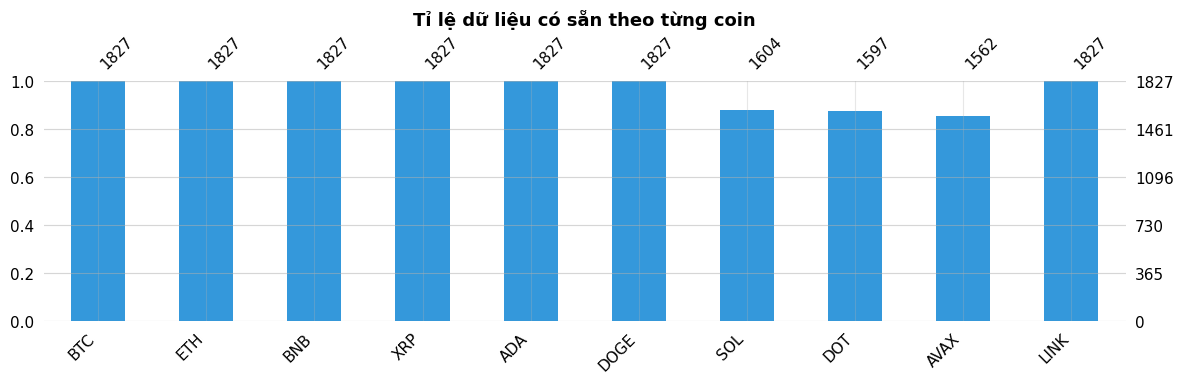

In [7]:
# Đếm số ngày thiếu dữ liệu của từng coin.
missing = df_close.isnull().sum()

# Tính tỉ lệ thiếu để so sánh công bằng giữa các coin.
missing_pct = (missing / len(df_close) * 100).round(2)

# Xác định ngày đầu tiên có dữ liệu thật của từng coin.
first_valid = df_close.apply(lambda s: s.first_valid_index())

# Tạo bảng báo cáo missing values gồm số ngày thiếu, tỉ lệ thiếu và ghi chú nguyên nhân.
df_missing_report = pd.DataFrame({
    "Số ngày thiếu": missing,
    "Tỉ lệ thiếu (%)": missing_pct,
    "Ngày đầu có dữ liệu": first_valid,
    "Ghi chú": ["Coin niêm yết sau 01/01/2020" if missing[c] > 0 else "Đủ dữ liệu" for c in df_close.columns]
})

# In tiêu đề báo cáo missing values.
print("Báo cáo giá trị thiếu:")

# In bảng báo cáo ở dạng text để nhìn rõ từng coin.
print(df_missing_report.to_string())

# Tạo khung biểu đồ cho missingno.
fig, ax = plt.subplots(figsize=(12, 4))

# Vẽ tỉ lệ dữ liệu có sẵn theo từng coin.
msno.bar(df_close, ax=ax, color="#3498db", fontsize=11)

# Đặt tiêu đề biểu đồ để nêu rõ nội dung đang kiểm tra.
ax.set_title("Tỉ lệ dữ liệu có sẵn theo từng coin", fontsize=13, fontweight="bold")

# Căn chỉnh layout để nhãn và tiêu đề không bị chồng lên nhau.
plt.tight_layout()

# Hiển thị biểu đồ.
plt.show()


**Ý nghĩa phân tích:** Biểu đồ missing values cho biết mức độ đầy đủ của dữ liệu theo từng coin. Những khoảng thiếu ở SOL, DOT và AVAX phản ánh việc các coin này có dữ liệu muộn hơn, không phải lỗi thu thập dữ liệu.

**Quyết định hỗ trợ:** Không nên so sánh tổng lợi nhuận của SOL/DOT/AVAX trực tiếp với BTC/ETH nếu không nhắc đến độ dài chuỗi dữ liệu khác nhau. Khi ra quyết định chọn coin để phân tích sâu hoặc đầu tư mô phỏng, cần ưu tiên dữ liệu đủ dài hoặc chuẩn hóa theo ngày đầu có dữ liệu.


In [8]:
# Định nghĩa hàm làm sạch missing values sau ngày niêm yết.
def fill_after_listing(df):
    """Chỉ forward-fill các NaN nằm sau ngày có giá đầu tiên; giữ nguyên NaN trước ngày niêm yết."""

    # Tạo bản sao để không làm thay đổi DataFrame gốc.
    df_filled = df.copy()

    # Xử lý từng coin riêng vì mỗi coin có ngày bắt đầu dữ liệu khác nhau.
    for coin in df.columns:

        # Tìm ngày đầu tiên coin có dữ liệu hợp lệ.
        first_idx = df[coin].first_valid_index()

        # Nếu coin có dữ liệu, chỉ fill từ ngày đầu tiên đó trở đi.
        if first_idx is not None:
            df_filled.loc[first_idx:, coin] = df_filled.loc[first_idx:, coin].ffill()

    # Trả về bảng đã xử lý missing values.
    return df_filled

# Làm sạch bảng giá đóng cửa để tính return và xu hướng.
df_close_clean = fill_after_listing(df_close)

# Làm sạch bảng volume để phân tích thanh khoản.
df_volume_clean = fill_after_listing(df_volume)

# Làm sạch bảng số giao dịch để phân tích hoạt động thị trường.
df_trades_clean = fill_after_listing(df_trades)

# Làm sạch bảng high để tính ATH và biên độ trong ngày.
df_high_clean = fill_after_listing(df_high)

# Làm sạch bảng low để tính biên độ High-Low.
df_low_clean = fill_after_listing(df_low)

# In tiêu đề kiểm chứng sau khi làm sạch.
print("Kiểm chứng xử lý missing values:")

# Kiểm tra các coin có khả năng niêm yết muộn.
for coin in [c for c in ["SOL", "DOT", "AVAX", "LINK"] if c in df_close_clean.columns]:

    # Lấy ngày đầu có dữ liệu sau xử lý.
    first = df_close_clean[coin].first_valid_index()

    # In ngày đầu dữ liệu để xác nhận không tạo dữ liệu giả trước niêm yết.
    print(f"  {coin:6s}: ngày đầu có dữ liệu = {first.date() if first else 'N/A'}")

# In kết luận xử lý missing values.
print("\nXử lý missing values hoàn tất.")


Kiểm chứng xử lý missing values:
  SOL   : ngày đầu có dữ liệu = 2020-08-11
  DOT   : ngày đầu có dữ liệu = 2020-08-18
  AVAX  : ngày đầu có dữ liệu = 2020-09-22
  LINK  : ngày đầu có dữ liệu = 2020-01-01

Xử lý missing values hoàn tất.


In [9]:
# Đặt ngày bắt đầu chính thức của phạm vi phân tích.
analysis_start = pd.Timestamp("2020-01-01")

# Đặt ngày kết thúc chính thức của phạm vi phân tích.
analysis_end = pd.Timestamp("2024-12-31")

# In tiêu đề kiểm tra phạm vi dữ liệu.
print("Kiểm tra phạm vi dữ liệu OHLCV dùng cho phân tích chính:")

# Lặp qua từng bảng để kiểm tra có dòng nào nằm ngoài 2020-2024 hay không.
for name, df in [("Close", df_close), ("Volume", df_volume), ("Trades", df_trades), ("High", df_high), ("Low", df_low), ("Open", df_open)]:

    # Lọc các dòng nằm ngoài phạm vi nghiên cứu.
    outside = df[(df.index < analysis_start) | (df.index > analysis_end)]

    # In phạm vi ngày thực tế và số dòng ngoài phạm vi.
    print(f"  {name:7s}: {df.index.min().date()} -> {df.index.max().date()} | số dòng ngoài 2020-2024 = {len(outside)}")

# In phần kết luận kiểm tra phạm vi.
print("\nKết luận kiểm tra:")

# Kết luận dữ liệu đúng phạm vi.
print("  - Dữ liệu OHLCV nằm đúng trong khoảng 2020-2024.")

# Khẳng định các phần sau chỉ dùng dữ liệu đã kiểm tra.
print("  - Các phân tích tiếp theo chỉ sử dụng dữ liệu trong phạm vi này.")


Kiểm tra phạm vi dữ liệu OHLCV dùng cho phân tích chính:
  Close  : 2020-01-01 -> 2024-12-31 | số dòng ngoài 2020-2024 = 0
  Volume : 2020-01-01 -> 2024-12-31 | số dòng ngoài 2020-2024 = 0
  Trades : 2020-01-01 -> 2024-12-31 | số dòng ngoài 2020-2024 = 0
  High   : 2020-01-01 -> 2024-12-31 | số dòng ngoài 2020-2024 = 0
  Low    : 2020-01-01 -> 2024-12-31 | số dòng ngoài 2020-2024 = 0
  Open   : 2020-01-01 -> 2024-12-31 | số dòng ngoài 2020-2024 = 0

Kết luận kiểm tra:
  - Dữ liệu OHLCV nằm đúng trong khoảng 2020-2024.
  - Các phân tích tiếp theo chỉ sử dụng dữ liệu trong phạm vi này.


## 4. Phân tích giá & xu hướng <a id='sec4'></a>

Phần này tập trung vào xu hướng giá đóng cửa, tốc độ tăng trưởng và return theo năm của từng coin trong giai đoạn 2020-2024.

**Giải thích thuật ngữ:**
- **Giá đóng cửa (Close price)** là giá cuối ngày giao dịch, thường được dùng làm giá đại diện cho ngày đó.
- **MA30 (Moving Average 30 ngày)** là trung bình động của 30 ngày gần nhất, giúp làm mượt biến động ngắn hạn để nhìn xu hướng chính rõ hơn.
- **Giá chuẩn hóa** là đưa tất cả coin về cùng mốc ban đầu, ví dụ 100, để so sánh tốc độ tăng trưởng tương đối dù giá gốc của các coin rất khác nhau.
- **Return** là tỉ suất sinh lời, tức phần trăm tăng/giảm của giá so với mốc trước đó. Return dương là tăng, return âm là giảm.

**Ý nghĩa trong phạm vi phân tích:** nhóm phân tích này trả lời câu hỏi coin nào tăng trưởng tốt hơn, xu hướng giá có bền hay không và hiệu suất thay đổi như thế nào qua từng năm.


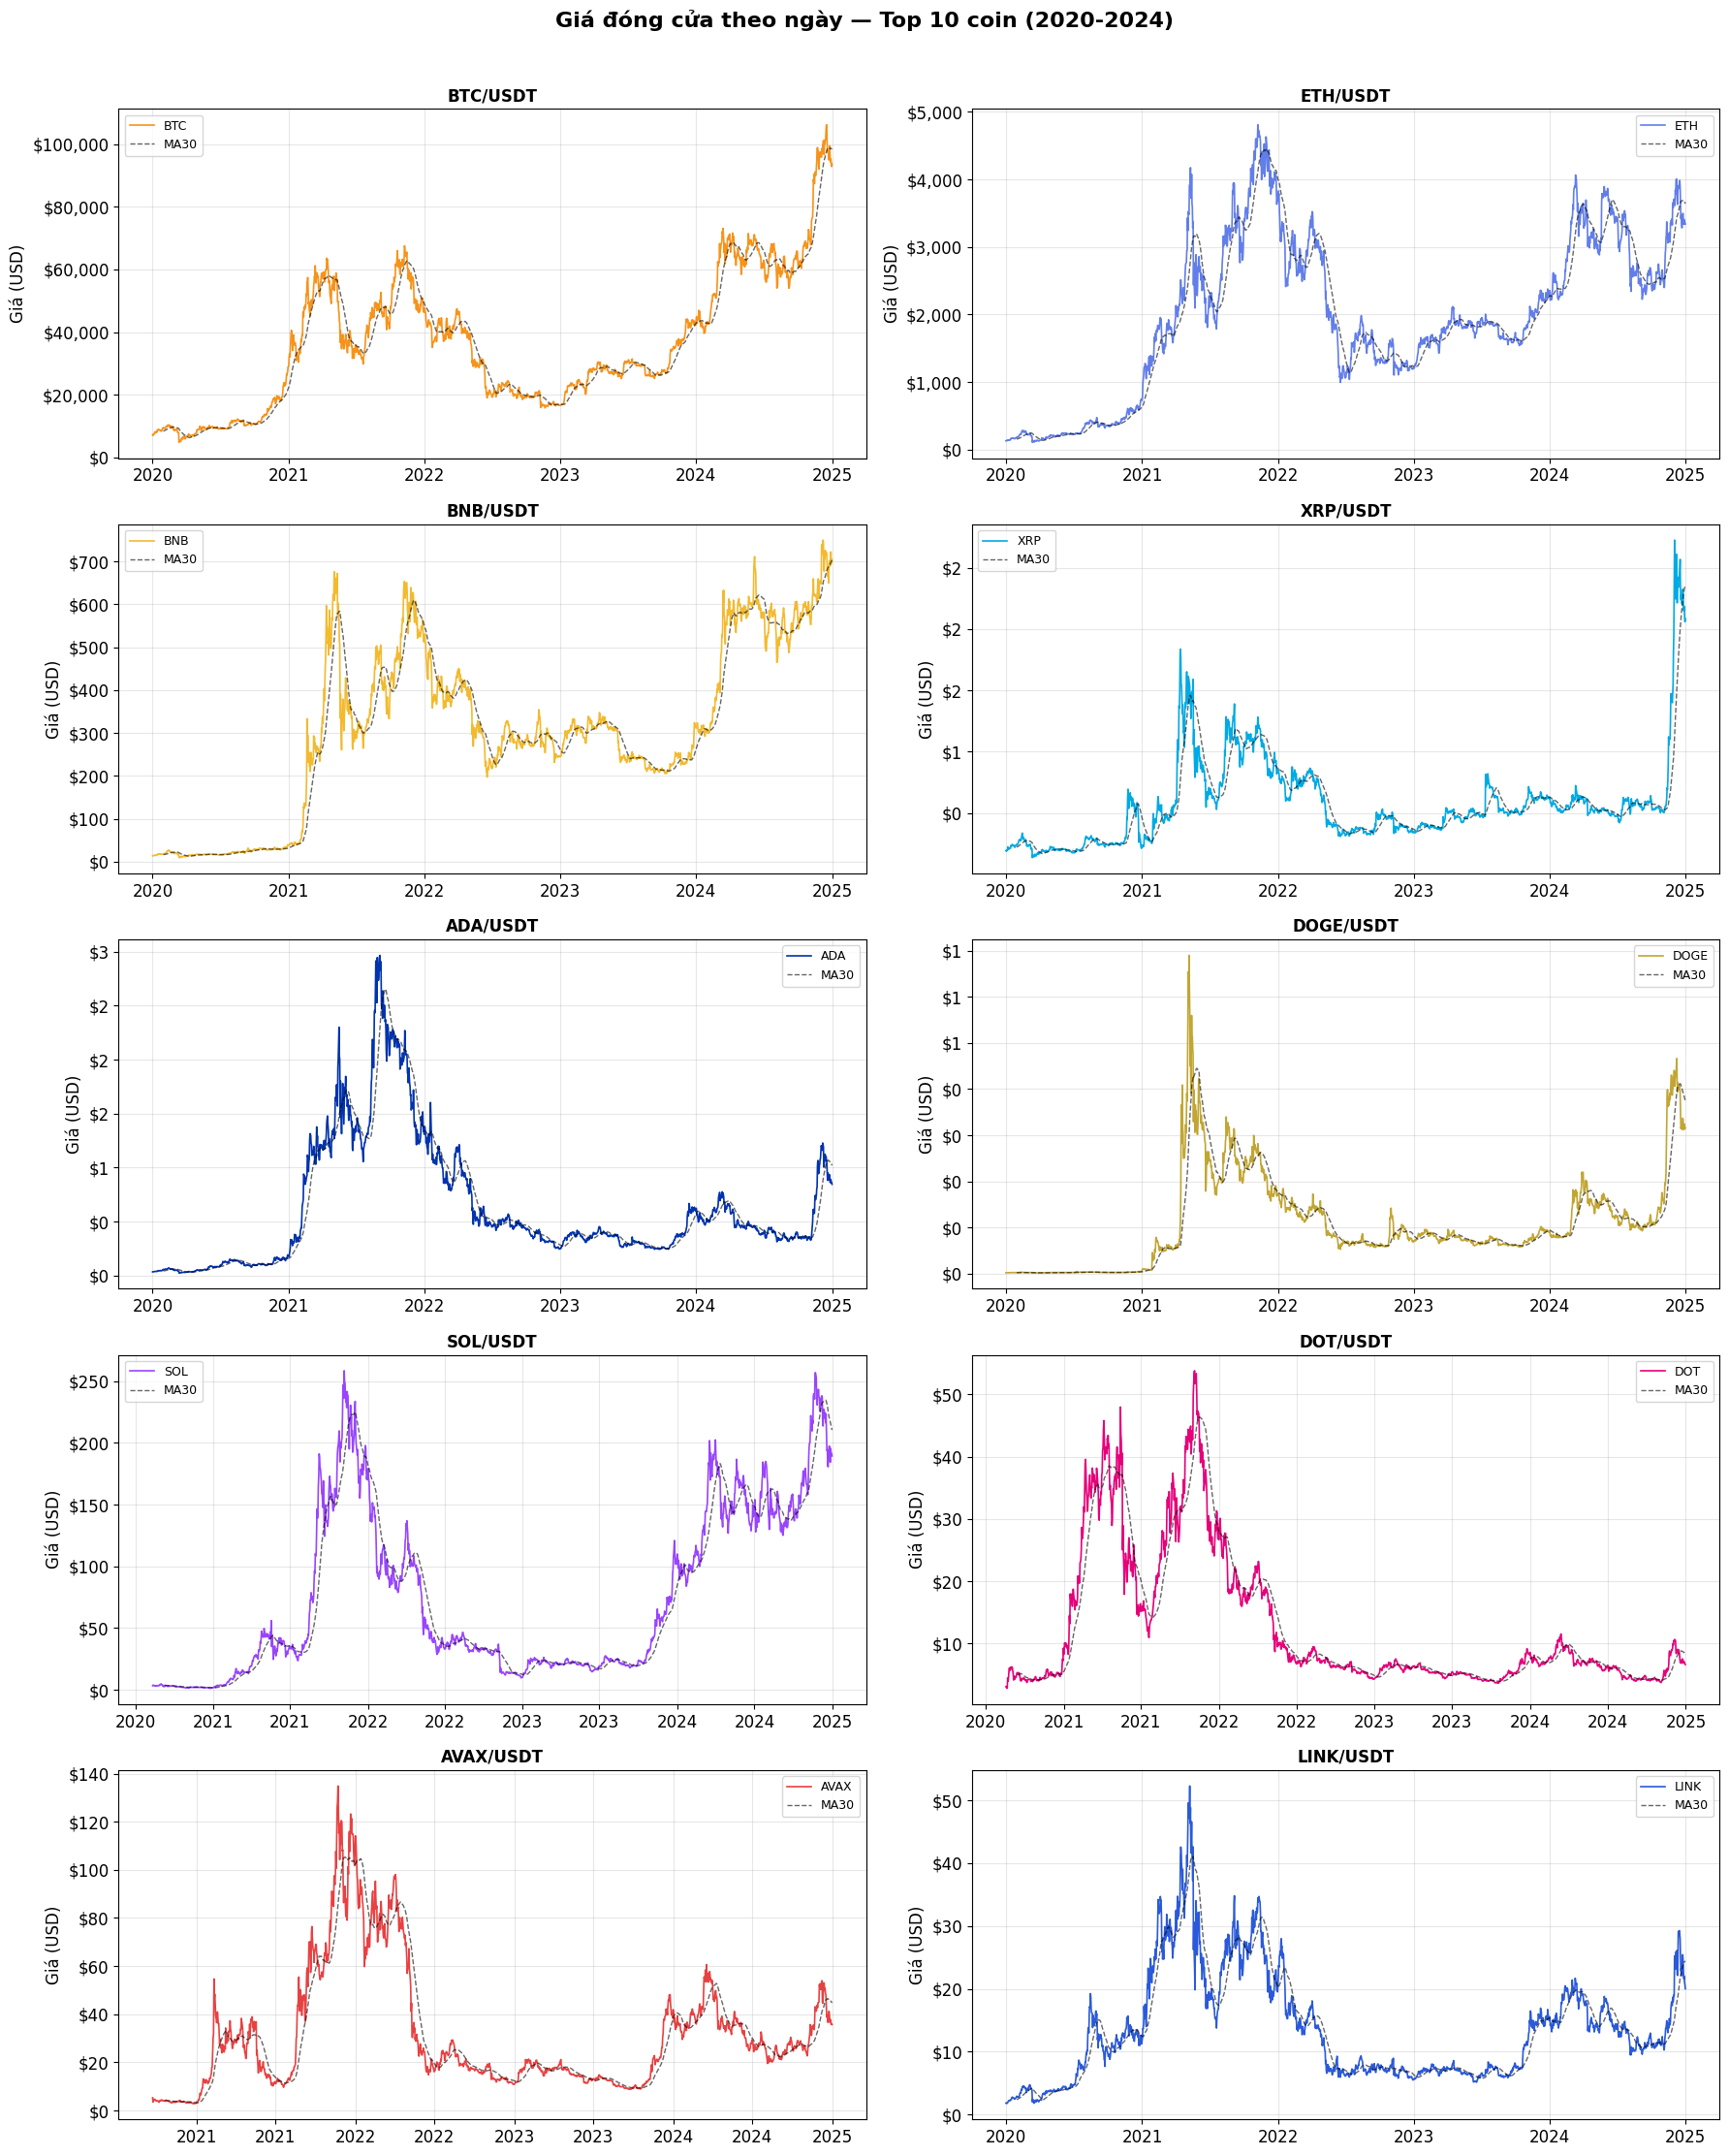

In [10]:
# 4.1 Giá đóng cửa theo thời gian
# Mục tiêu: quan sát xu hướng dài hạn và so sánh giá với đường trung bình động MA30.
fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()

for i, coin in enumerate(df_close_clean.columns):
    ax = axes[i]
    color = COIN_COLORS.get(coin, "#3498db")

    # Lấy chuỗi giá đóng cửa hợp lệ và tính MA30 để làm mượt biến động ngắn hạn.
    series = df_close_clean[coin].dropna()
    ma30 = series.rolling(30).mean()

    # Vẽ giá đóng cửa và MA30 trên cùng một biểu đồ con.
    ax.plot(series.index, series, color=color, linewidth=1.2, label=coin)
    ax.plot(ma30.index, ma30, color="black", linewidth=1, linestyle="--", alpha=0.6, label="MA30")
    ax.set_title(f"{coin}/USDT", fontweight="bold", fontsize=12)
    ax.set_ylabel("Giá (USD)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: "$" + format(x, ",.0f")))
    ax.legend(fontsize=9)

plt.suptitle("Giá đóng cửa theo ngày — Top 10 coin (2020-2024)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Biểu đồ giá đóng cửa giúp quan sát xu hướng dài hạn của từng coin trong giai đoạn 2020-2024. Đường MA30 làm mượt nhiễu ngắn hạn để thấy xu hướng chính rõ hơn.

**Quyết định hỗ trợ:** Nếu giá duy trì xu hướng tăng và nằm trên MA30 trong thời gian dài, có thể xem là tín hiệu theo dõi mua/giữ trong chiến lược xu hướng. Nếu giá giảm kéo dài hoặc thường xuyên nằm dưới MA30, nên thận trọng, giảm tỉ trọng hoặc chờ tín hiệu hồi phục rõ hơn.


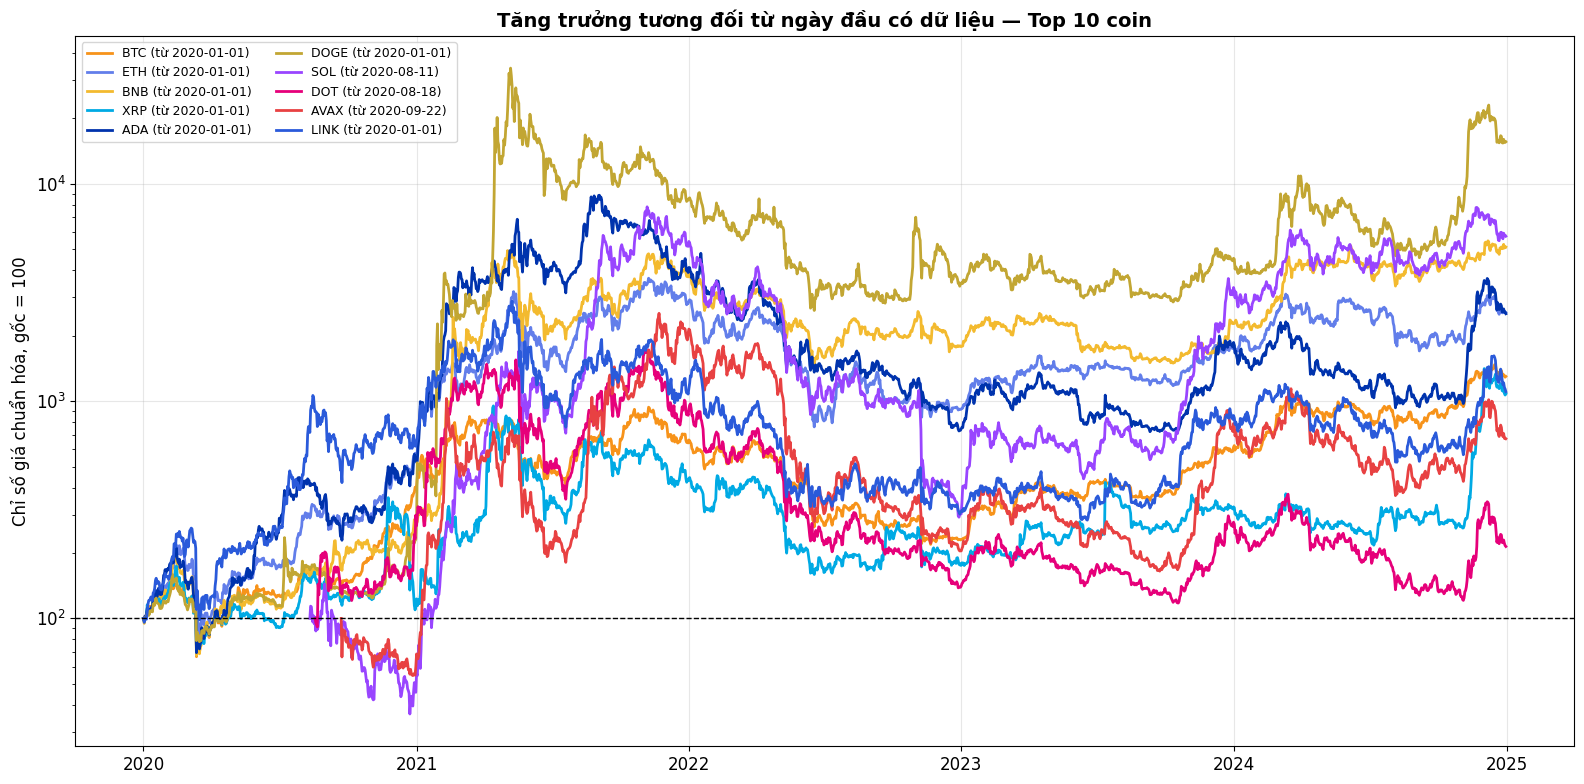

In [11]:
# 4.2 Giá chuẩn hóa
# Mục tiêu: đưa tất cả coin về cùng mốc 100 để so sánh tăng trưởng tương đối.
fig, ax = plt.subplots(figsize=(16, 8))

for coin in df_close_clean.columns:
    # Bỏ NaN trước ngày niêm yết, lấy ngày đầu có dữ liệu làm mốc 100.
    series = df_close_clean[coin].dropna()
    norm = series / series.iloc[0] * 100
    label = f"{coin} (từ {series.index[0].date()})"
    ax.plot(norm.index, norm, label=label, linewidth=2, color=COIN_COLORS.get(coin, "#999"))

# Đường 100 là mốc ban đầu; trên 100 là tăng, dưới 100 là giảm so với ngày đầu.
ax.axhline(100, color="black", linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_ylabel("Chỉ số giá chuẩn hóa, gốc = 100")
ax.set_title("Tăng trưởng tương đối từ ngày đầu có dữ liệu — Top 10 coin", fontsize=14, fontweight="bold")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Giá chuẩn hóa đưa mỗi coin về cùng mốc 100 tại ngày đầu tiên có dữ liệu, nhờ đó có thể so sánh tốc độ tăng trưởng tương đối thay vì bị ảnh hưởng bởi đơn vị giá gốc của từng coin.

**Quyết định hỗ trợ:** Coin có đường chuẩn hóa tăng mạnh nhưng biến động quá lớn phù hợp với chiến lược chấp nhận rủi ro cao; coin tăng ổn định hơn phù hợp với chiến lược nắm giữ thận trọng. Biểu đồ này hỗ trợ quyết định chọn coin vào danh mục mô phỏng theo khẩu vị rủi ro.


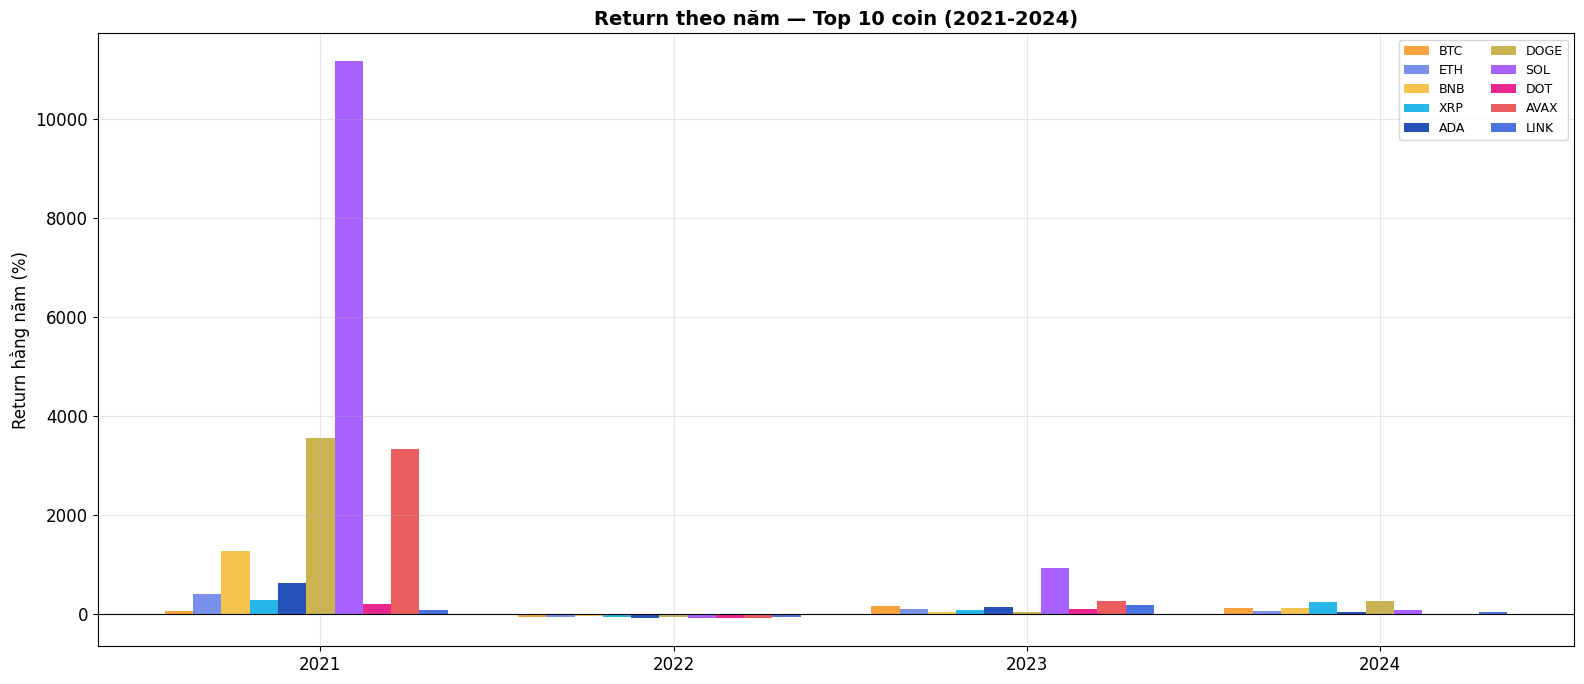


Return theo năm (%) — từ 2021:
date  2021-12-31  2022-12-31  2023-12-31  2024-12-31
BTC         59.8       -64.2       155.6       121.3
ETH        399.2       -67.5        90.8        46.3
BNB       1268.9       -51.8        26.6       125.2
XRP        277.8       -59.2        81.6       238.5
ADA        621.3       -81.2       141.7        42.3
DOGE      3546.0       -58.7        27.5       252.9
SOL      11177.8       -94.1       920.3        86.1
DOT        187.8       -83.8        90.3       -19.0
AVAX      3334.8       -90.0       253.7        -7.4
LINK        73.6       -71.4       168.0        33.9


In [12]:
# 4.3 Return theo năm
# Mục tiêu: đo hiệu suất từng coin theo từng năm thay vì chỉ nhìn giá cuối kỳ.
df_yearly = df_close_clean.resample("YE").last()

# pct_change tính mức thay đổi phần trăm giữa giá cuối năm hiện tại và cuối năm trước.
df_yearly_return = df_yearly.pct_change() * 100

# Lấy từ 2021 vì return năm 2020 không có năm trước trong bộ dữ liệu để so sánh.
valid_years = df_yearly_return.loc["2021":]

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(valid_years))
width = 0.08

# Vẽ grouped bar chart: mỗi năm gồm 10 cột tương ứng 10 coin.
for i, coin in enumerate(df_close_clean.columns):
    returns = valid_years[coin].values
    offset = (i - len(df_close_clean.columns) / 2) * width
    ax.bar(x + offset, returns, width, label=coin, color=COIN_COLORS.get(coin, "#999"), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(valid_years.index.year)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Return hằng năm (%)")
ax.set_title("Return theo năm — Top 10 coin (2021-2024)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

print("\nReturn theo năm (%) — từ 2021:")
print(valid_years.round(1).T.to_string())


**Ý nghĩa phân tích:** Return theo năm cho biết năm nào thị trường tăng trưởng mạnh, năm nào điều chỉnh mạnh. Chỉ số này giúp so sánh hiệu suất từng coin theo từng năm thay vì chỉ nhìn giá cuối kỳ.

**Quyết định hỗ trợ:** Nếu một coin tăng mạnh trong năm thị trường thuận lợi nhưng giảm sâu trong năm xấu, cần đặt giới hạn rủi ro và không nên mua đuổi ở cuối chu kỳ tăng. Coin giữ return tương đối tốt qua nhiều năm có thể được ưu tiên cho chiến lược nắm giữ dài hạn hơn.


## 5. Phân tích biến động (Volatility) <a id='sec5'></a>

Phần này đo mức độ dao động của daily return để đánh giá rủi ro biến động giá của từng coin.

**Giải thích thuật ngữ:**
- **Daily return** là phần trăm thay đổi giá đóng cửa giữa hai ngày liên tiếp. Công thức đơn giản là: (giá hôm nay / giá hôm qua - 1) x 100%.
- **Volatility** là mức độ biến động của giá hoặc return. Volatility càng cao thì giá càng dao động mạnh, rủi ro càng lớn.
- **Độ lệch chuẩn (standard deviation)** đo mức độ phân tán của daily return quanh giá trị trung bình. Trong phạm vi phân tích này, độ lệch chuẩn daily return được dùng làm thước đo volatility.
- **Rolling volatility 30 ngày** là volatility được tính liên tục trên cửa sổ 30 ngày gần nhất, giúp thấy rủi ro thay đổi theo thời gian.

**Ý nghĩa trong phạm vi phân tích:** phần này không chỉ nói coin nào lời nhiều, mà còn cho biết coin nào rủi ro hơn. Đây là cơ sở để đưa ra quyết định phân bổ vốn và quản trị rủi ro.


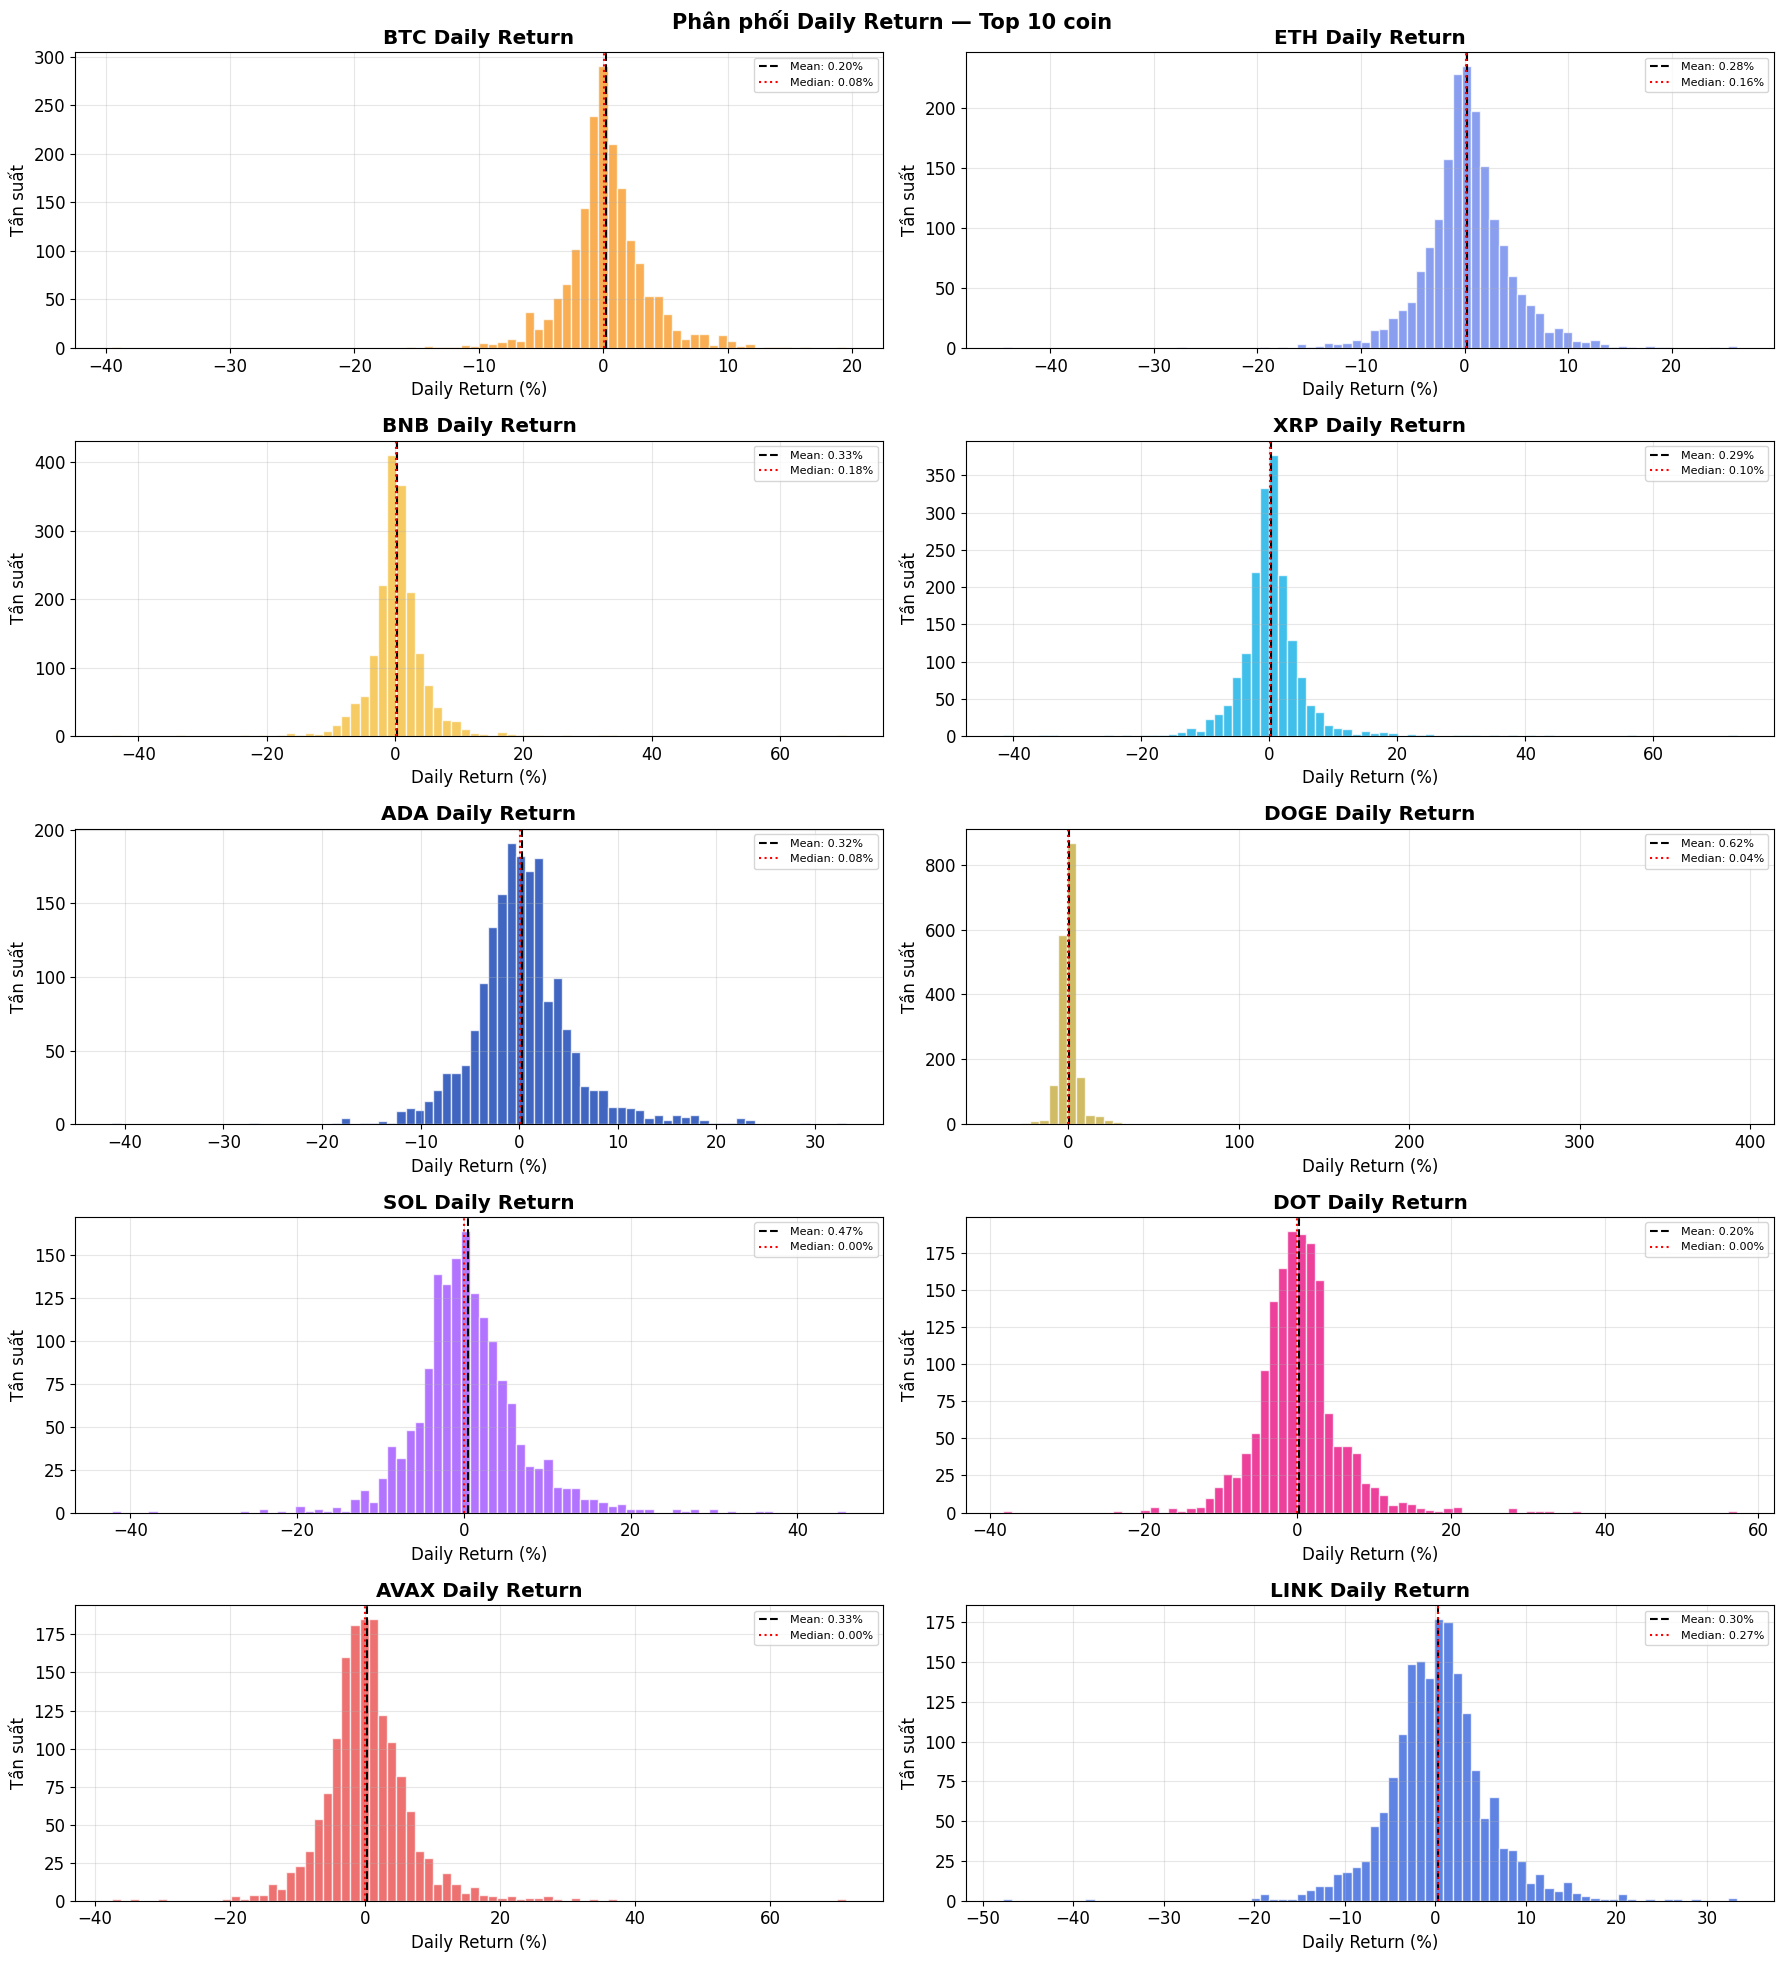

In [13]:
# Daily return: tỉ suất sinh lời hằng ngày tính từ giá đóng cửa.
# pct_change tạo NaN ở ngày đầu; NaN trước ngày niêm yết được giữ để tránh dữ liệu giả.
df_daily_return = df_close_clean.pct_change() * 100

# 5.1 Phân phối Daily Return
# Mục tiêu: xem return thường tập trung quanh đâu và có nhiều ngày cực trị hay không.
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for i, coin in enumerate(df_daily_return.columns):
    ax = axes[i]
    ret = df_daily_return[coin].dropna()
    color = COIN_COLORS.get(coin, "#3498db")

    # Histogram thể hiện tần suất xuất hiện của các mức return hằng ngày.
    ax.hist(ret, bins=80, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(ret.mean(), color="black", linestyle="--", label=f"Mean: {ret.mean():.2f}%")
    ax.axvline(ret.median(), color="red", linestyle=":", label=f"Median: {ret.median():.2f}%")
    ax.set_title(f"{coin} Daily Return", fontweight="bold")
    ax.set_xlabel("Daily Return (%)")
    ax.set_ylabel("Tần suất")
    ax.legend(fontsize=8)

plt.suptitle("Phân phối Daily Return — Top 10 coin", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Phân phối daily return cho thấy mức độ dao động thường ngày của từng coin. Phân phối càng rộng hoặc có nhiều giá trị cực trị thì coin đó càng có rủi ro biến động cao.

**Quyết định hỗ trợ:** Coin có phân phối return quá rộng cần giảm tỉ trọng, đặt stop-loss rộng hơn hoặc chỉ phù hợp với nhà đầu tư chịu rủi ro cao. Coin có phân phối hẹp hơn phù hợp hơn với chiến lược ổn định, nhưng vẫn cần kết hợp xu hướng giá trước khi quyết định mua/bán.


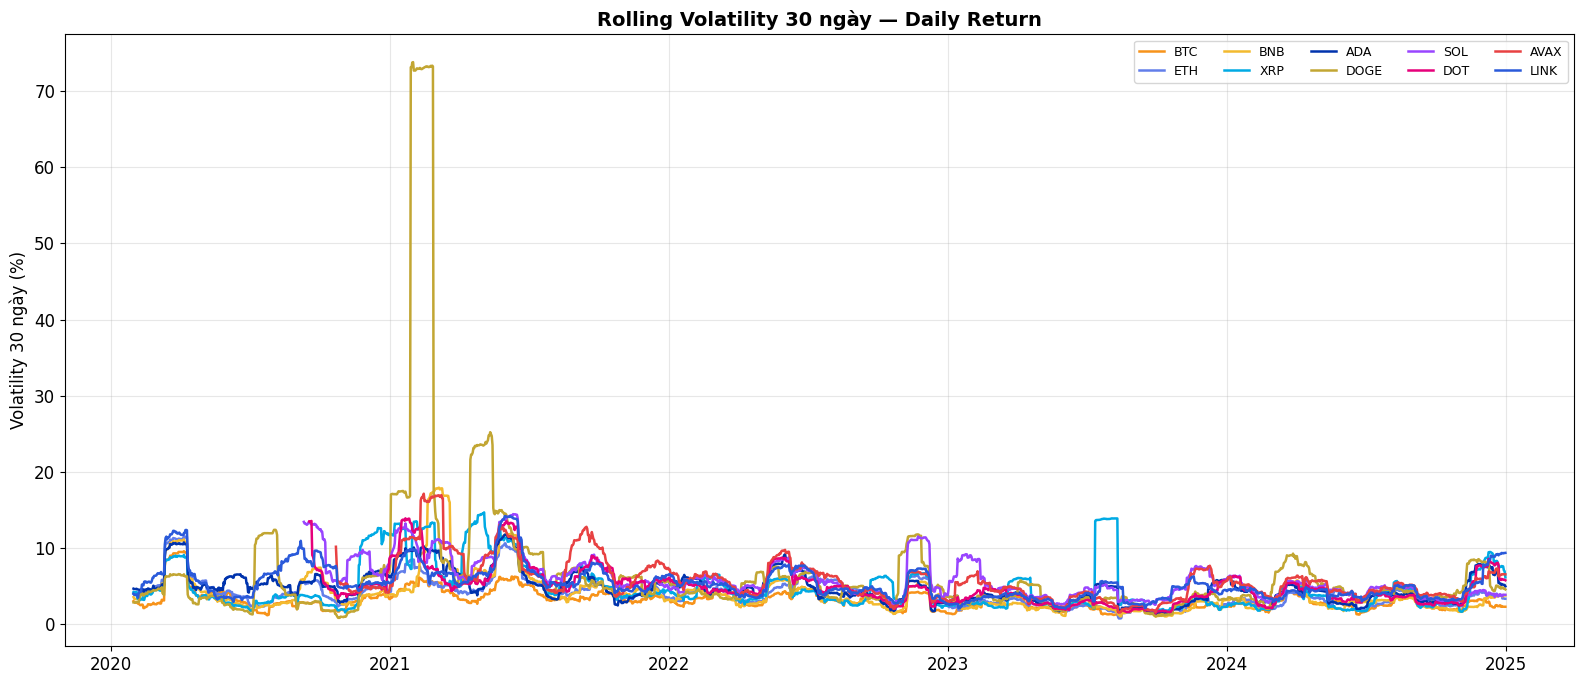

In [14]:
# 5.2 Rolling Volatility
# Mục tiêu: đo rủi ro biến động theo thời gian bằng độ lệch chuẩn return trong cửa sổ 30 ngày.
df_volatility = df_daily_return.rolling(30).std()

fig, ax = plt.subplots(figsize=(16, 7))
for coin in df_volatility.columns:
    series = df_volatility[coin].dropna()
    ax.plot(series.index, series, label=coin, linewidth=1.8, color=COIN_COLORS.get(coin, "#999"))

ax.set_ylabel("Volatility 30 ngày (%)")
ax.set_title("Rolling Volatility 30 ngày — Daily Return", fontsize=14, fontweight="bold")
ax.legend(ncol=5, fontsize=9)
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Rolling volatility 30 ngày cho thấy rủi ro biến động thay đổi theo thời gian. Các giai đoạn volatility tăng mạnh thường tương ứng với thời điểm thị trường bất ổn hoặc điều chỉnh lớn.

**Quyết định hỗ trợ:** Khi volatility tăng đột biến, nên hạn chế mở vị thế mới, giảm đòn bẩy hoặc giảm tỉ trọng. Khi volatility hạ nhiệt sau giai đoạn cao, có thể xem xét quay lại quan sát cơ hội mua nếu xu hướng giá cũng cải thiện.


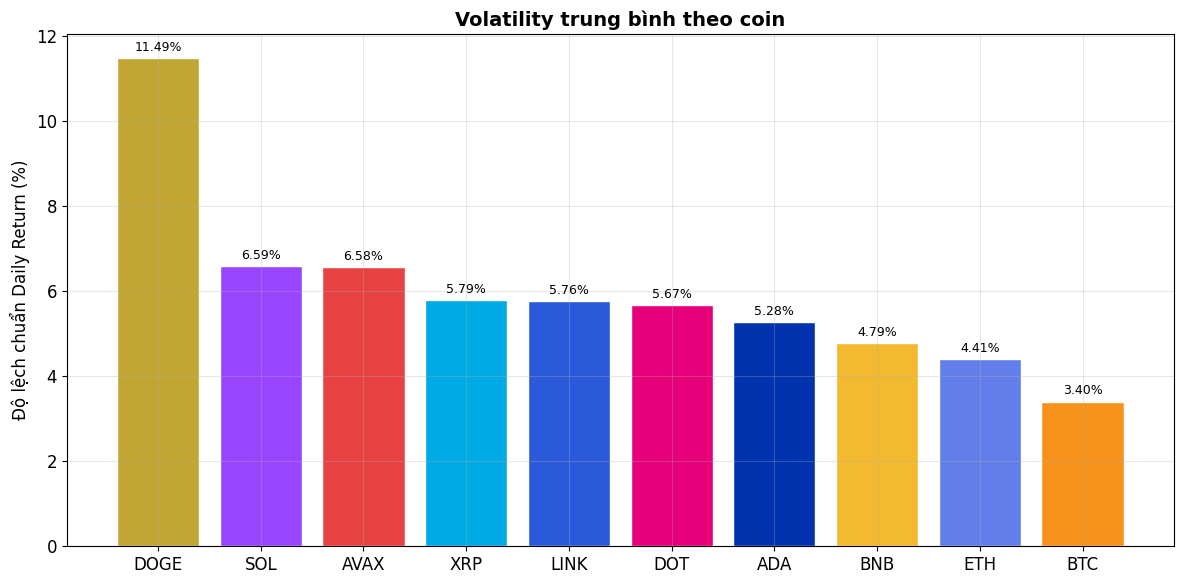

Volatility trung bình (%/ngày):
DOGE    11.486
SOL      6.593
AVAX     6.575
XRP      5.788
LINK     5.763
DOT      5.669
ADA      5.277
BNB      4.791
ETH      4.415
BTC      3.405


In [15]:
# 5.3 So sánh volatility trung bình
# Mục tiêu: xếp hạng coin theo mức rủi ro biến động trong toàn giai đoạn.Rolling Volatility 
avg_vol = df_daily_return.std().sort_values(ascending=False)
colors_vol = [COIN_COLORS.get(c, "#999") for c in avg_vol.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(avg_vol.index, avg_vol.values, color=colors_vol, edgecolor="white")
ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=9)
ax.set_ylabel("Độ lệch chuẩn Daily Return (%)")
ax.set_title("Volatility trung bình theo coin", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Volatility trung bình (%/ngày):")
print(avg_vol.round(3).to_string())


**Ý nghĩa phân tích:** So sánh volatility trung bình giúp xếp hạng coin theo mức độ rủi ro. Coin có độ lệch chuẩn daily return cao hơn thường được xem là biến động mạnh hơn và rủi ro hơn.

**Quyết định hỗ trợ:** Kết quả này hỗ trợ phân bổ vốn: coin volatility cao chỉ nên chiếm tỉ trọng nhỏ hơn trong danh mục, còn coin volatility thấp hơn có thể dùng làm phần ổn định tương đối. Đây là tiêu chí quản trị rủi ro, không phải tín hiệu mua/bán độc lập.


## 6. Phân tích tương quan (Correlation) <a id='sec6'></a>

Phần này đánh giá mức độ di chuyển cùng chiều giữa BTC và các altcoin, đặc biệt thông qua daily return trong khoảng thời gian chung.

**Giải thích thuật ngữ:**
- **Correlation (tương quan)** đo mức độ hai biến di chuyển cùng nhau. Giá trị gần 1 nghĩa là thường tăng/giảm cùng chiều; gần -1 nghĩa là thường ngược chiều; gần 0 nghĩa là quan hệ yếu.
- **Tương quan giá** cho biết giá của các coin có xu hướng cùng tăng hoặc cùng giảm trong dài hạn hay không.
- **Tương quan daily return** quan trọng hơn trong quản trị rủi ro vì nó cho biết biến động hằng ngày của các coin có đi cùng nhau hay không.
- **Khoảng thời gian chung** là giai đoạn mà tất cả coin đều có dữ liệu, giúp so sánh công bằng khi tính correlation.
- **Scatter plot** là biểu đồ điểm, mỗi điểm là một ngày, dùng để nhìn trực quan mối quan hệ giữa return của BTC và return của từng altcoin.

**Ý nghĩa trong phạm vi phân tích:** phần này trả lời câu hỏi danh mục nhiều coin có thật sự đa dạng hóa hay không. Nếu các coin tương quan cao với BTC, danh mục vẫn có thể giảm mạnh khi BTC giảm.


Khoảng thời gian chung của 10 coin:
  Từ: 2020-09-22 -> 2024-12-31
  Số ngày: 1,562


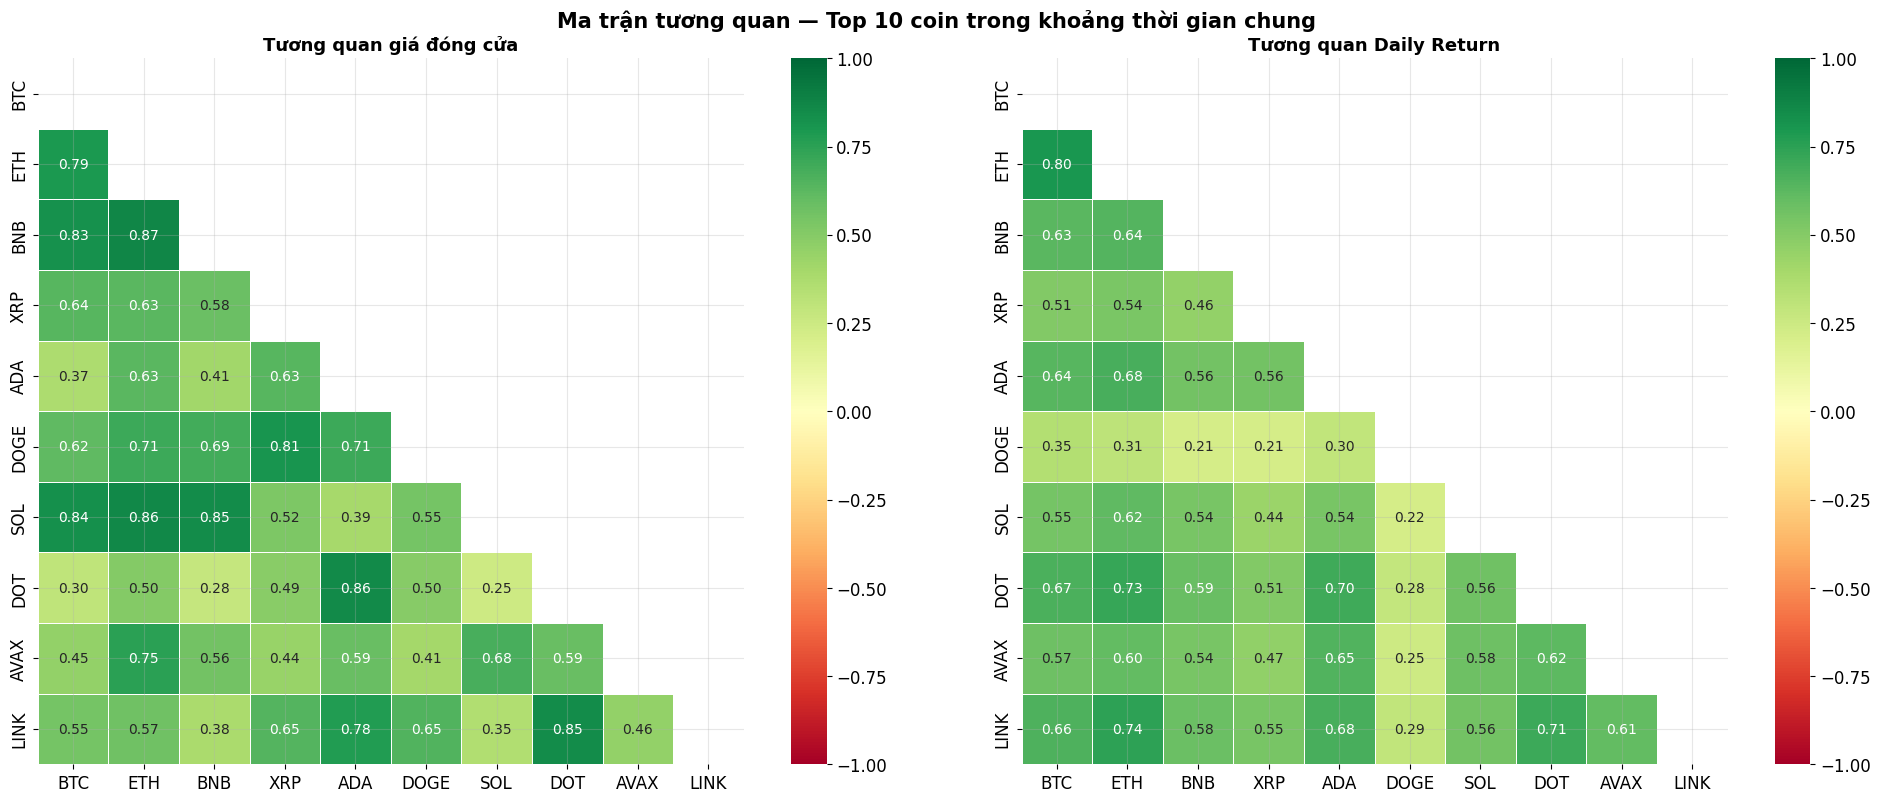

In [16]:
# Dùng khoảng thời gian chung để tất cả 10 coin đều có dữ liệu.
# Điều này giúp correlation không bị lệch do coin niêm yết muộn.
common_start = df_close_clean.apply(lambda s: s.first_valid_index()).max()
df_close_common = df_close_clean.loc[common_start:]
df_return_common = df_close_common.pct_change().dropna() * 100

print("Khoảng thời gian chung của 10 coin:")
print(f"  Từ: {common_start.date()} -> {df_close_common.index.max().date()}")
print(f"  Số ngày: {len(df_close_common):,}")

# Tính correlation trên giá đóng cửa và trên daily return để so sánh hai góc nhìn.
corr_price = df_close_common.corr()
corr_return = df_return_common.corr()
mask1 = np.triu(np.ones_like(corr_price, dtype=bool))
mask2 = np.triu(np.ones_like(corr_return, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(corr_price, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1, center=0,
            ax=axes[0], linewidths=0.5, square=True, mask=mask1, annot_kws={"size": 10})
axes[0].set_title("Tương quan giá đóng cửa", fontsize=13, fontweight="bold")

sns.heatmap(corr_return, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1, center=0,
            ax=axes[1], linewidths=0.5, square=True, mask=mask2, annot_kws={"size": 10})
axes[1].set_title("Tương quan Daily Return", fontsize=13, fontweight="bold")

plt.suptitle("Ma trận tương quan — Top 10 coin trong khoảng thời gian chung", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Ma trận tương quan cho biết các coin có xu hướng di chuyển cùng chiều hay ngược chiều. Tương quan Daily Return có ý nghĩa hơn tương quan giá vì phản ánh mối quan hệ biến động ngắn hạn giữa các coin.

**Quyết định hỗ trợ:** Nếu nhiều coin tương quan cao với BTC, việc mua nhiều coin đó không làm danh mục đa dạng hóa đáng kể. Khi xây danh mục, nên tránh tập trung quá nhiều vào các coin có tương quan quá cao và cần cân nhắc tài sản/coin có hành vi khác biệt hơn.


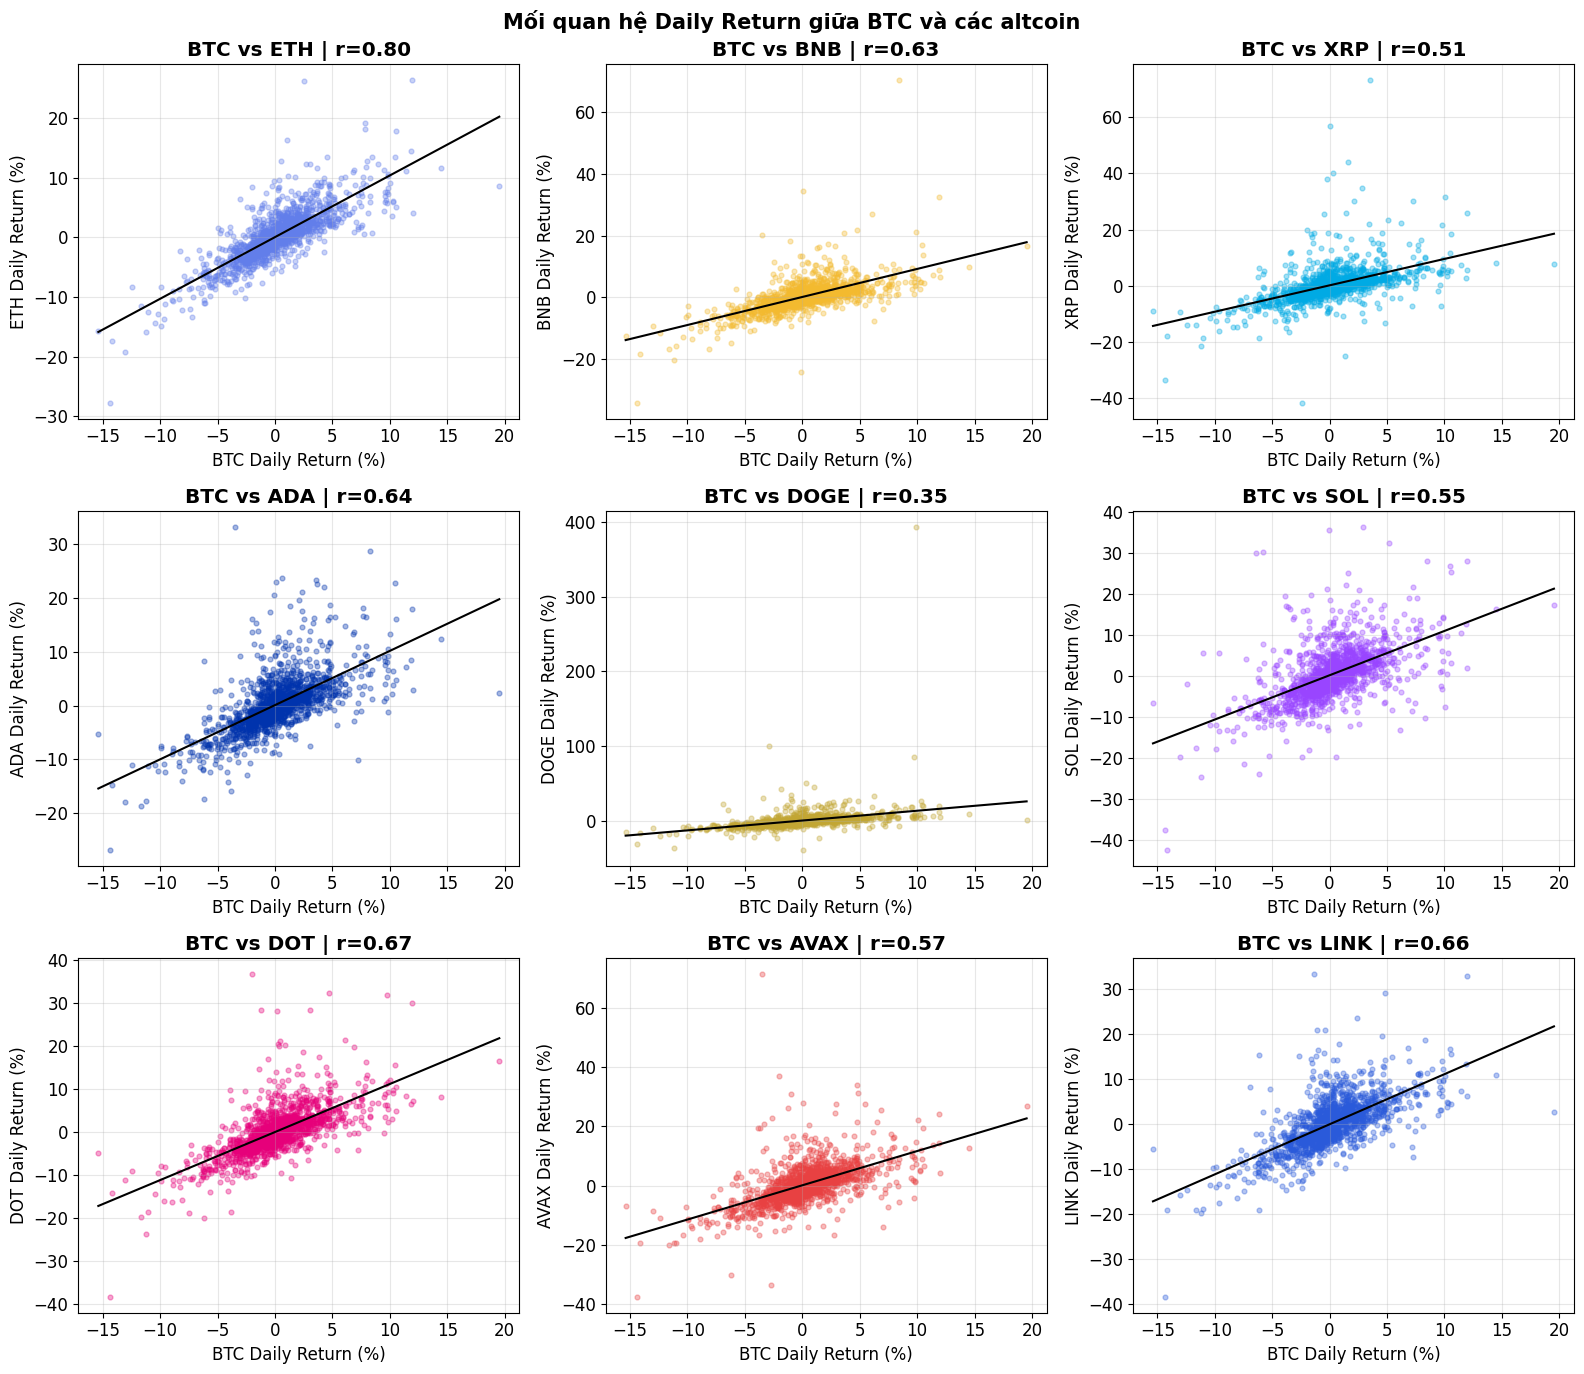

In [17]:
# 6.2 Scatter plot BTC với các coin còn lại
# Mục tiêu: kiểm tra mức độ nhạy của từng altcoin khi BTC biến động.
coins_vs_btc = [c for c in df_return_common.columns if c != "BTC"]
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, coin in enumerate(coins_vs_btc):
    ax = axes[i]
    x = df_return_common["BTC"]
    y = df_return_common[coin]

    # Mỗi điểm là một ngày: trục x là return BTC, trục y là return altcoin.
    ax.scatter(x, y, s=12, alpha=0.35, color=COIN_COLORS.get(coin, "#999"))

    # Đường hồi quy tuyến tính giúp nhìn xu hướng altcoin tăng/giảm theo BTC.
    slope, intercept, r, p, stderr = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="black", linewidth=1.5)
    ax.set_title(f"BTC vs {coin} | r={r:.2f}", fontweight="bold")
    ax.set_xlabel("BTC Daily Return (%)")
    ax.set_ylabel(f"{coin} Daily Return (%)")

for j in range(len(coins_vs_btc), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mối quan hệ Daily Return giữa BTC và các altcoin", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Scatter plot BTC với từng altcoin giúp quan sát trực quan mức độ altcoin biến động theo BTC. Đám mây điểm càng nghiêng lên rõ thì mối quan hệ cùng chiều với BTC càng mạnh.

**Quyết định hỗ trợ:** Altcoin có quan hệ quá mạnh với BTC thường chịu ảnh hưởng lớn khi BTC giảm, nên quyết định mua altcoin cần theo dõi xu hướng BTC trước. Nếu BTC đang yếu, nên hạn chế mua các altcoin có độ nhạy cao với BTC.


## 7. Phân tích Volume & Trades <a id='sec7'></a>

Phần này xem xét thanh khoản và mức độ hoạt động giao dịch, từ đó đánh giá liệu các ngày giao dịch sôi động có đi kèm biến động giá lớn hay không.

**Giải thích thuật ngữ:**
- **Volume** là khối lượng coin được giao dịch trong ngày. Volume cao thường cho thấy thị trường quan tâm nhiều hơn và thanh khoản tốt hơn.
- **Trades** là số lượng giao dịch trong ngày. Trades cao cho thấy thị trường hoạt động sôi động hơn.
- **Thanh khoản** là khả năng mua/bán tài sản dễ dàng mà không làm giá thay đổi quá mạnh.
- **|Return|** là giá trị tuyệt đối của return, dùng để đo độ lớn biến động mà không quan tâm tăng hay giảm.
- **Spearman correlation** là tương quan theo thứ hạng, phù hợp khi dữ liệu lệch mạnh hoặc có nhiều giá trị đột biến như volume.
- **log(Volume + 1)** giúp giảm ảnh hưởng của những ngày volume quá lớn, để biểu đồ dễ đọc và tương quan ổn định hơn.

**Ý nghĩa trong phạm vi phân tích:** phần này giúp đánh giá liệu biến động giá có đi kèm thanh khoản hay không. Đây là cơ sở để ra quyết định về thời điểm giao dịch và mức độ rủi ro khi vào/ra vị thế.


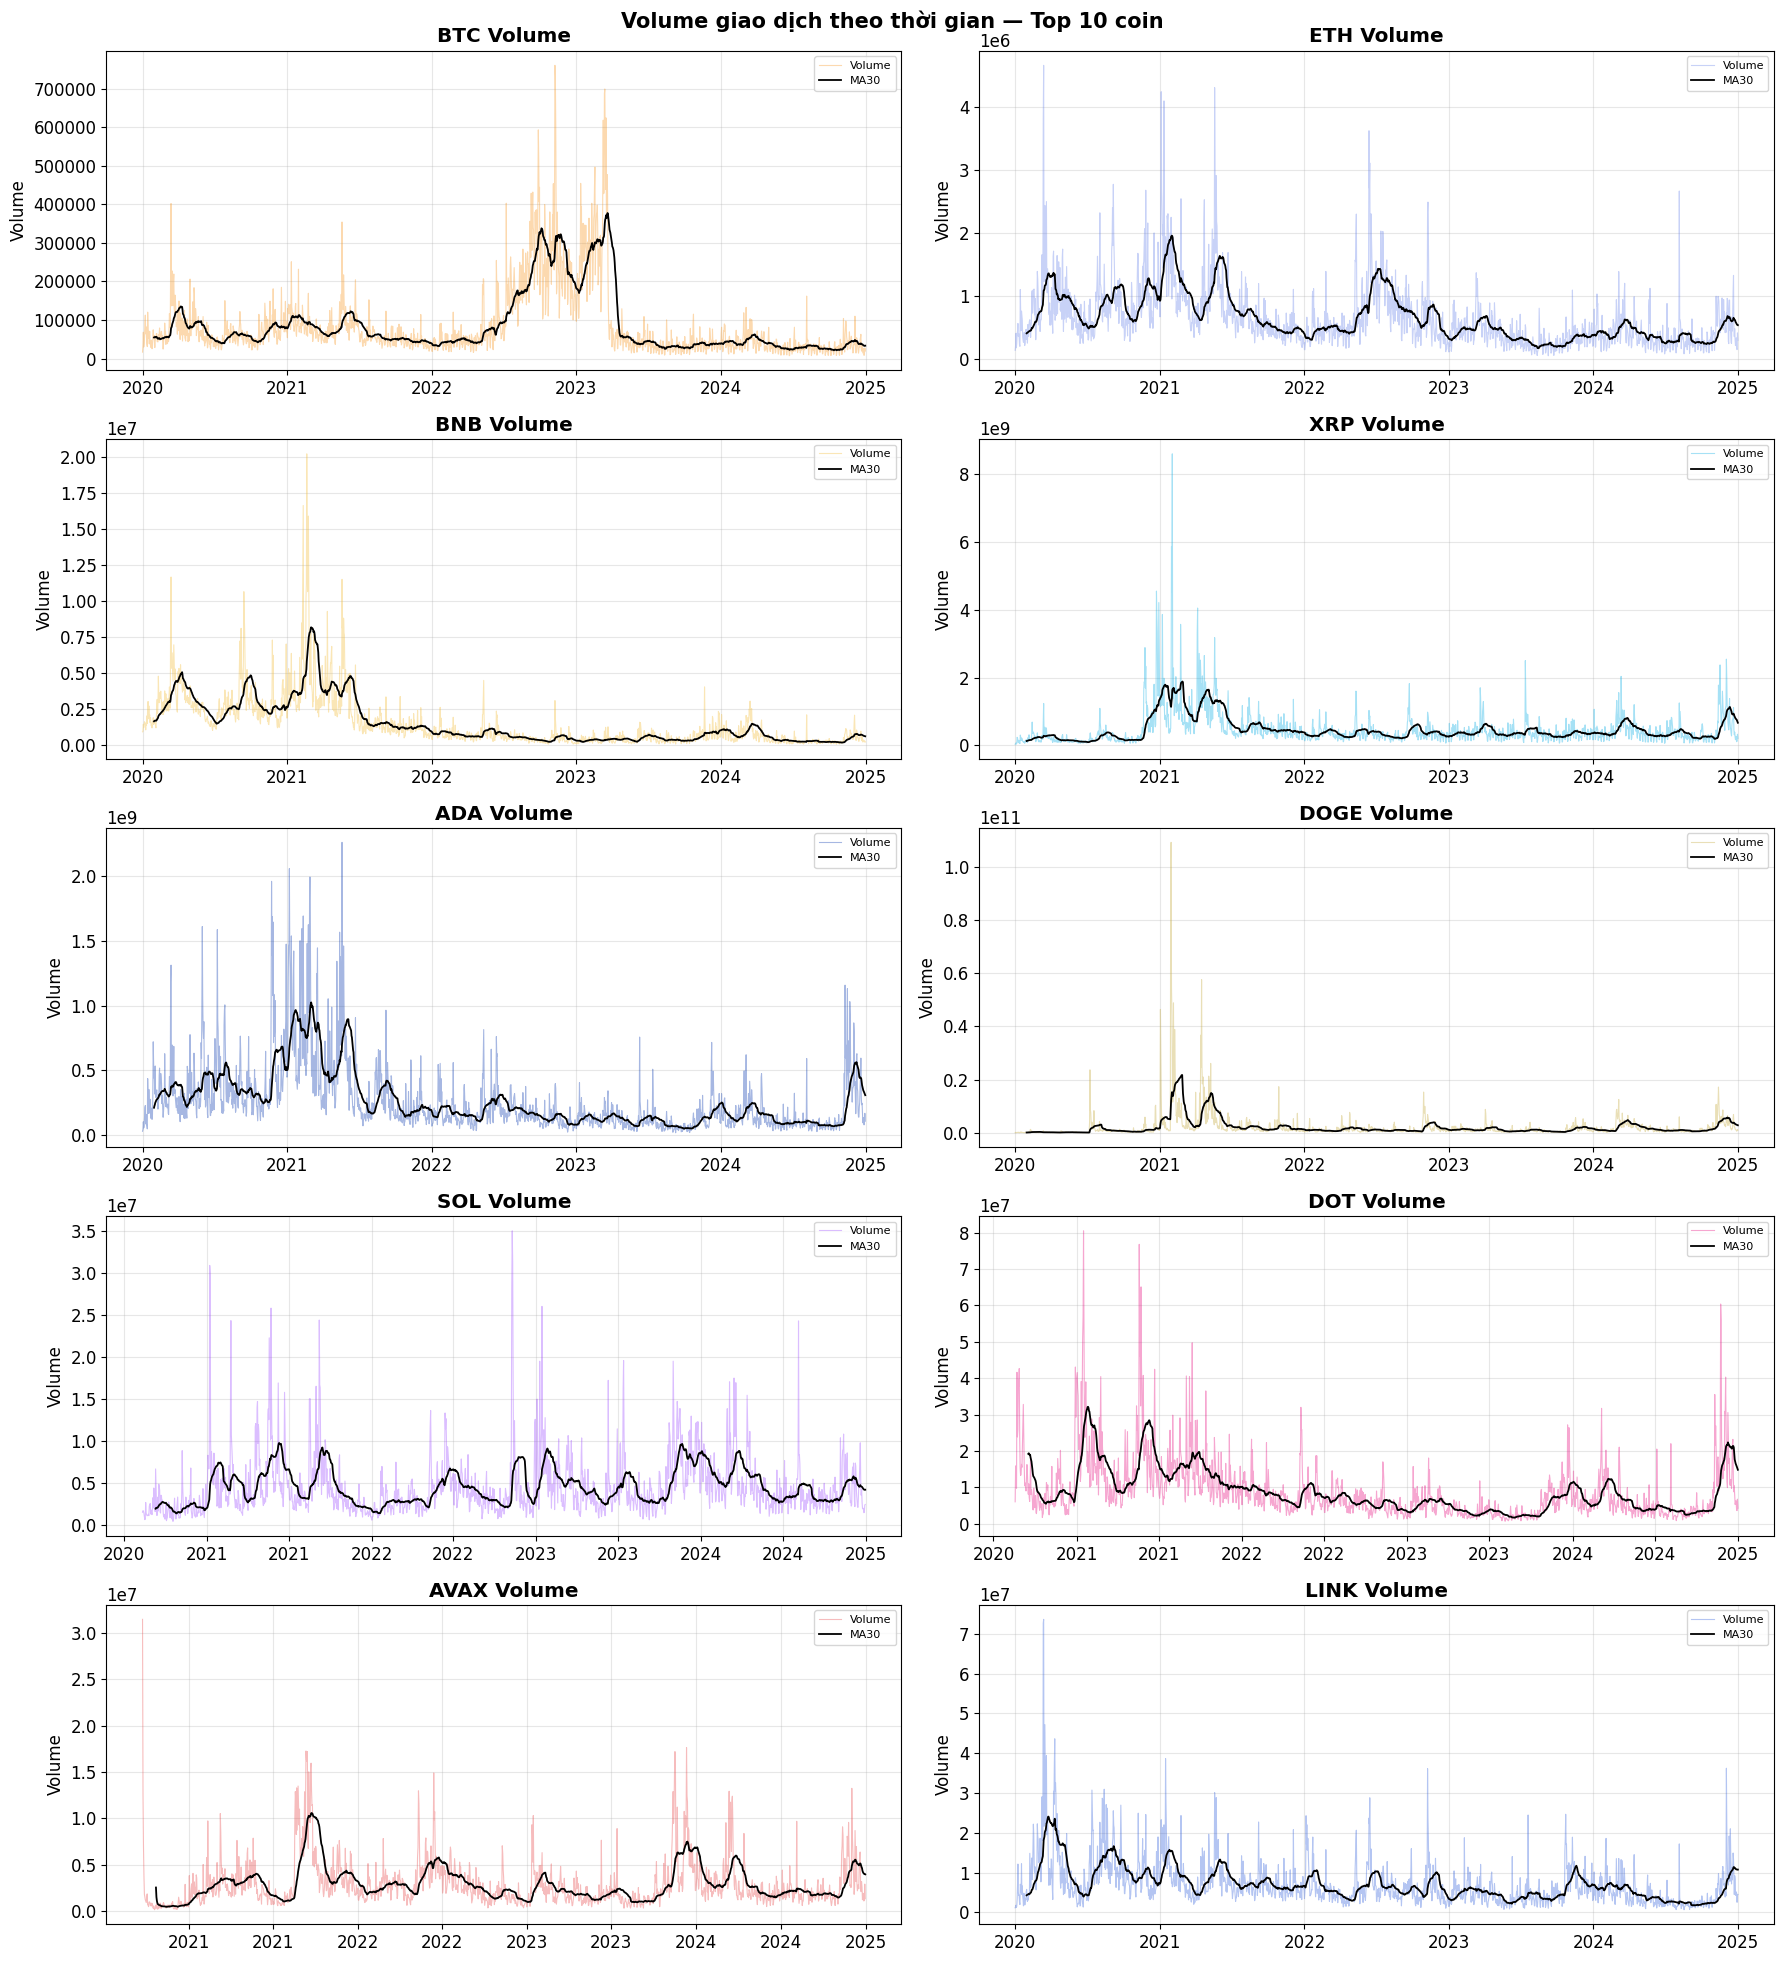

In [18]:
# 7.1 Volume theo thời gian
# Mục tiêu: quan sát thanh khoản và các giai đoạn thị trường giao dịch sôi động.
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for i, coin in enumerate(df_volume_clean.columns):
    ax = axes[i]
    color = COIN_COLORS.get(coin, "#3498db")

    # Volume gốc thường nhiễu, nên vẽ thêm MA30 để quan sát xu hướng thanh khoản.
    vol = df_volume_clean[coin].dropna()
    vol_ma30 = vol.rolling(30).mean()
    ax.plot(vol.index, vol, color=color, alpha=0.35, linewidth=0.8, label="Volume")
    ax.plot(vol_ma30.index, vol_ma30, color="black", linewidth=1.3, label="MA30")
    ax.set_title(f"{coin} Volume", fontweight="bold")
    ax.set_ylabel("Volume")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=8)

plt.suptitle("Volume giao dịch theo thời gian — Top 10 coin", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Volume theo thời gian thể hiện mức độ thanh khoản và sự quan tâm của thị trường đối với từng coin. Các đợt volume tăng đột biến thường là dấu hiệu thị trường có sự kiện hoặc biến động lớn.

**Quyết định hỗ trợ:** Volume tăng cùng xu hướng giá tăng có thể củng cố tín hiệu mua/giữ; volume tăng trong lúc giá giảm mạnh là tín hiệu cảnh báo rủi ro bán tháo. Coin có thanh khoản thấp nên hạn chế tỉ trọng vì khó vào/ra vị thế ổn định.


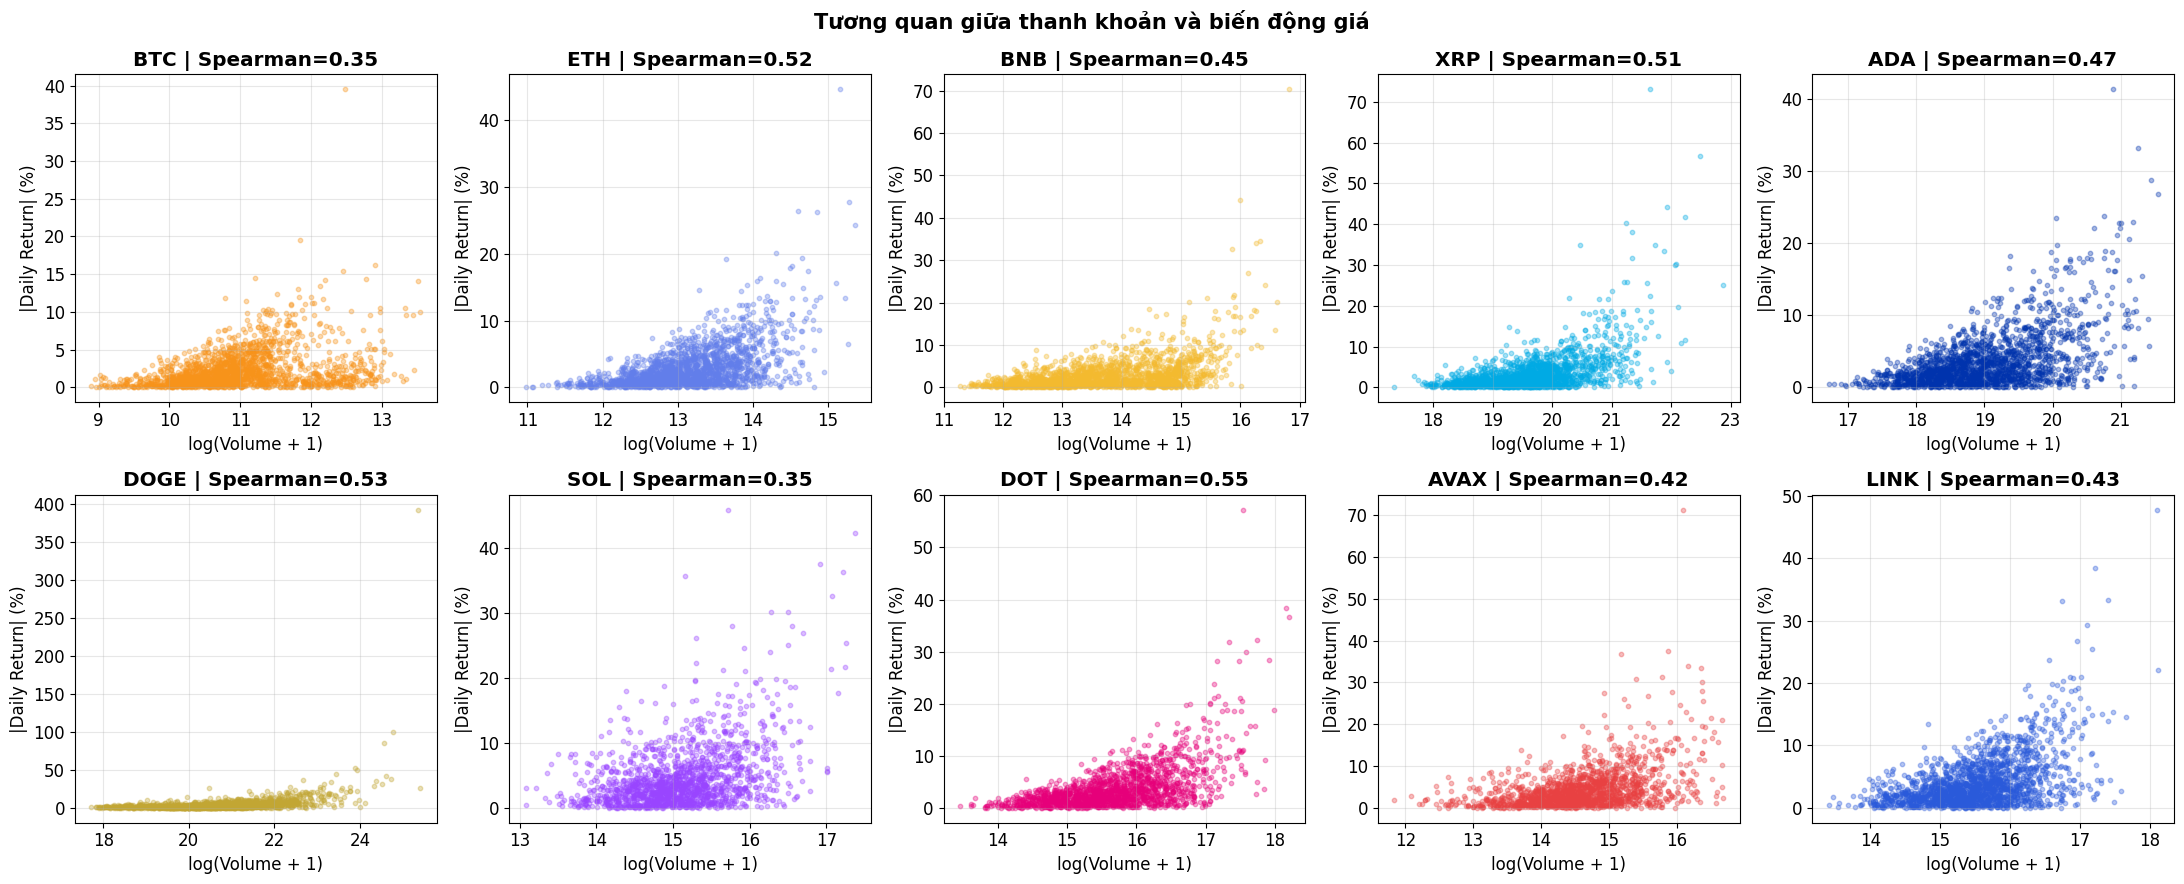

In [19]:
# 7.2 Tương quan log(Volume) với |Return| bằng Spearman
# Mục tiêu: kiểm tra ngày thanh khoản cao có đi kèm biến động giá mạnh hay không.
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, coin in enumerate(df_close_clean.columns):
    ax = axes[i]

    # Lấy volume và độ lớn tuyệt đối của daily return trên cùng tập ngày.
    vol = df_volume_clean[coin].dropna()
    ret_abs = df_daily_return[coin].abs().dropna()
    common_idx = vol.index.intersection(ret_abs.index)

    # log1p giảm ảnh hưởng của các ngày volume quá lớn.
    x = np.log1p(vol.loc[common_idx])
    y = ret_abs.loc[common_idx]

    # Spearman đo tương quan theo thứ hạng, phù hợp với dữ liệu volume lệch phải.
    corr = x.corr(y, method="spearman")
    ax.scatter(x, y, s=10, alpha=0.35, color=COIN_COLORS.get(coin, "#999"))
    ax.set_title(f"{coin} | Spearman={corr:.2f}", fontweight="bold")
    ax.set_xlabel("log(Volume + 1)")
    ax.set_ylabel("|Daily Return| (%)")

plt.suptitle("Tương quan giữa thanh khoản và biến động giá", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Biểu đồ log(volume) và |return| kiểm tra liệu ngày giao dịch sôi động có đi kèm biến động giá lớn hay không. Spearman được dùng vì volume thường lệch phải và có nhiều giá trị đột biến.

**Quyết định hỗ trợ:** Nếu volume và |return| có tương quan dương, các ngày volume tăng bất thường cần được xem là tín hiệu cảnh báo biến động. Nhà đầu tư có thể dùng điều này để điều chỉnh stop-loss, giảm rủi ro hoặc tránh mua ngay trong phiên quá nhiễu.


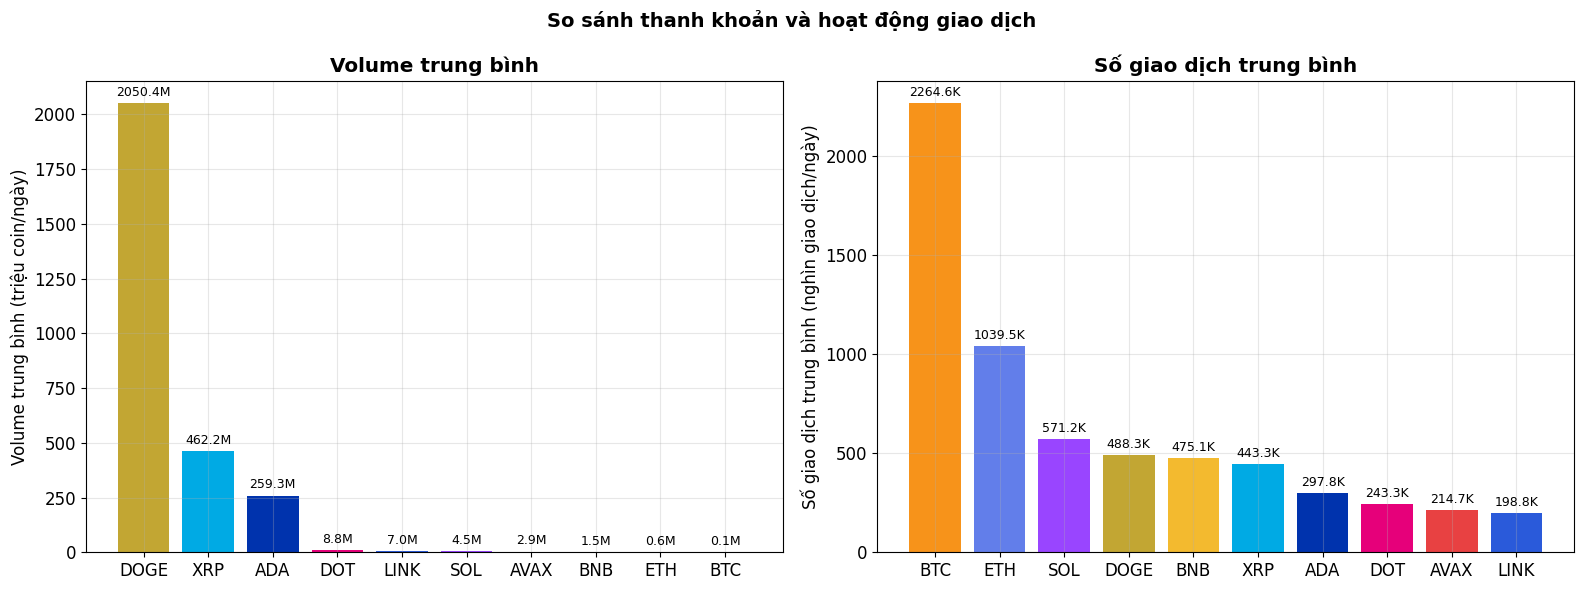

In [20]:
# 7.3 So sánh volume và số giao dịch trung bình
# Mục tiêu: đánh giá quy mô thanh khoản và mức độ hoạt động của từng coin.
avg_volume = df_volume_clean.mean().sort_values(ascending=False) / 1e6
avg_trades = df_trades_clean.mean().sort_values(ascending=False) / 1e3

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors1 = [COIN_COLORS.get(c, "#999") for c in avg_volume.index]
colors2 = [COIN_COLORS.get(c, "#999") for c in avg_trades.index]

# Biểu đồ trái: khối lượng giao dịch trung bình theo ngày.
bars1 = axes[0].bar(avg_volume.index, avg_volume.values, color=colors1)
axes[0].bar_label(bars1, fmt="%.1fM", padding=3, fontsize=9)
axes[0].set_title("Volume trung bình", fontweight="bold")
axes[0].set_ylabel("Volume trung bình (triệu coin/ngày)")

# Biểu đồ phải: số lượng giao dịch trung bình theo ngày.
bars2 = axes[1].bar(avg_trades.index, avg_trades.values, color=colors2)
axes[1].bar_label(bars2, fmt="%.1fK", padding=3, fontsize=9)
axes[1].set_title("Số giao dịch trung bình", fontweight="bold")
axes[1].set_ylabel("Số giao dịch trung bình (nghìn giao dịch/ngày)")

plt.suptitle("So sánh thanh khoản và hoạt động giao dịch", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** So sánh volume và số giao dịch trung bình giúp đánh giá quy mô thanh khoản của từng coin. Coin có volume/trades cao thường có mức độ hoạt động thị trường lớn hơn.

**Quyết định hỗ trợ:** Coin có thanh khoản cao phù hợp hơn cho chiến lược giao dịch vì giảm rủi ro trượt giá. Coin có thanh khoản thấp cần thận trọng khi mua/bán, đặc biệt nếu quy mô vị thế lớn hoặc cần thoát lệnh nhanh.


## 8. Phân tích OHLC & ATH <a id='sec8'></a>

Phần này khai thác các trường OHLC để quan sát cấu trúc giá, biên độ dao động trong ngày và đỉnh giá cao nhất trong giai đoạn 2020-2024.

**Giải thích thuật ngữ:**
- **Candlestick** là biểu đồ nến, thể hiện Open, High, Low, Close trong từng ngày. Thân nến và râu nến giúp nhìn áp lực mua/bán trong phiên.
- **High-Low Spread** là biên độ dao động trong ngày, tính bằng (High - Low) / Close. Chỉ số này càng cao thì trong ngày giá dao động càng mạnh.
- **ATH (All-Time High)** trong phạm vi phân tích này là mức giá cao nhất đạt được trong giai đoạn 2020-2024, tính từ cột High.
- **Close cuối 2024 so với ATH** cho biết tại cuối giai đoạn nghiên cứu, giá còn cách đỉnh bao xa.

**Ý nghĩa trong phạm vi phân tích:** phần này bổ sung góc nhìn chi tiết hơn so với chỉ dùng giá đóng cửa. Nó giúp đánh giá sức mạnh phục hồi, mức dao động trong ngày và vùng giá đỉnh của từng coin.


In [21]:
# 8.1 Candlestick BTC
# Mục tiêu: xem cấu trúc OHLC của BTC trong 180 ngày cuối giai đoạn nghiên cứu.
btc = binance_data["BTC"].copy()
btc_recent = btc.iloc[-180:]

# Candlestick dùng open, high, low, close để thể hiện biến động trong từng ngày.
fig = go.Figure(data=[go.Candlestick(
    x=btc_recent.index,
    open=btc_recent["open"], high=btc_recent["high"],
    low=btc_recent["low"], close=btc_recent["close"],
    increasing_line_color="#2ecc71",
    decreasing_line_color="#e74c3c",
    name="BTC/USDT"
)])
fig.update_layout(
    title="BTC/USDT Candlestick — 180 ngày cuối giai đoạn 2020-2024",
    yaxis_title="Giá (USD)",
    xaxis_title="Ngày",
    xaxis_rangeslider_visible=False,
    height=500,
    template="plotly_white"
)
fig.show()


**Ý nghĩa phân tích:** Candlestick BTC cho thấy cấu trúc giá trong 180 ngày cuối giai đoạn nghiên cứu, gồm giá mở cửa, cao nhất, thấp nhất và đóng cửa. Đây là cách nhìn chi tiết hơn so với chỉ quan sát giá đóng cửa.

**Quyết định hỗ trợ:** Candlestick giúp nhận diện vùng giá dao động, áp lực mua/bán và các phiên biến động mạnh. Với BTC, đây là biểu đồ tham chiếu quan trọng trước khi quyết định mua/giữ/bán các altcoin vì thị trường thường đi theo BTC.


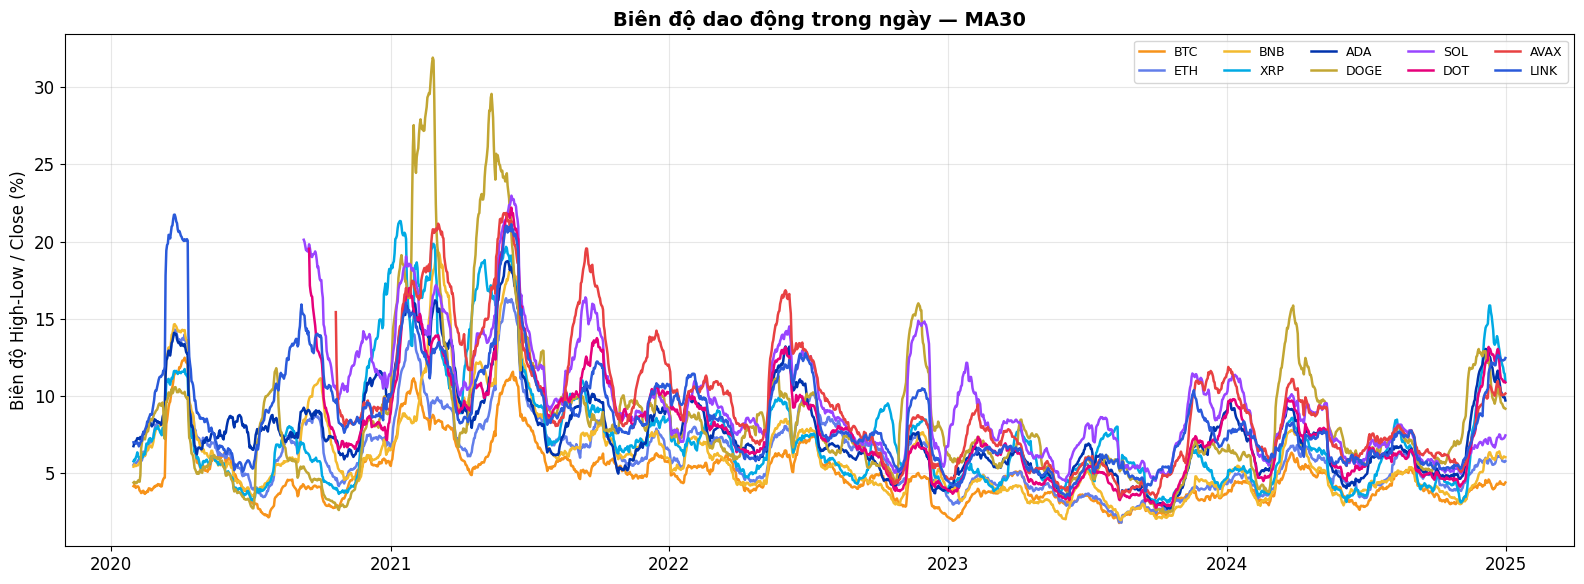

In [22]:
# 8.2 Biên độ High-Low hằng ngày
# Mục tiêu: đo mức dao động trong ngày bằng (High - Low) / Close.
df_spread = (df_high_clean - df_low_clean) / df_close_clean * 100

fig, ax = plt.subplots(figsize=(16, 6))
for coin in df_spread.columns:
    # Dùng MA30 để làm mượt biên độ dao động hằng ngày.
    spread_ma = df_spread[coin].dropna().rolling(30).mean()
    ax.plot(spread_ma.index, spread_ma, label=coin, linewidth=1.8, color=COIN_COLORS.get(coin, "#999"))

ax.set_ylabel("Biên độ High-Low / Close (%)")
ax.set_title("Biên độ dao động trong ngày — MA30", fontsize=14, fontweight="bold")
ax.legend(ncol=5, fontsize=9)
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** Biên độ High-Low phản ánh mức dao động trong ngày. Khi biên độ tăng, thị trường đang biến động mạnh hơn ngay trong phiên giao dịch.

**Quyết định hỗ trợ:** Khi biên độ trong ngày tăng cao, nên giảm quy mô lệnh hoặc chờ thị trường ổn định hơn. Biên độ thấp hơn giúp việc đặt điểm mua/bán và quản trị stop-loss dễ kiểm soát hơn.


ATH tính trong giai đoạn 2020-2024:
symbol  ath_2020_2024_usd   ath_date  close_2024_usd  drop_from_ath_2024_pct
   DOT            55.0900 2021-11-04          6.6430                   -87.9
  AVAX           147.0000 2021-11-21         35.7100                   -75.7
   ADA             3.1010 2021-09-02          0.8451                   -72.7
  LINK            53.0000 2021-05-10         20.0100                   -62.2
  DOGE             0.7400 2021-05-08          0.3160                   -57.3
   ETH          4868.0000 2021-11-10       3337.7800                   -31.4
   SOL           264.3900 2024-11-22        189.3100                   -28.4
   XRP             2.9092 2024-12-03          2.0836                   -28.4
   BTC        108353.0000 2024-12-17      93576.0000                   -13.6
   BNB           793.8600 2024-12-04        702.3000                   -11.5


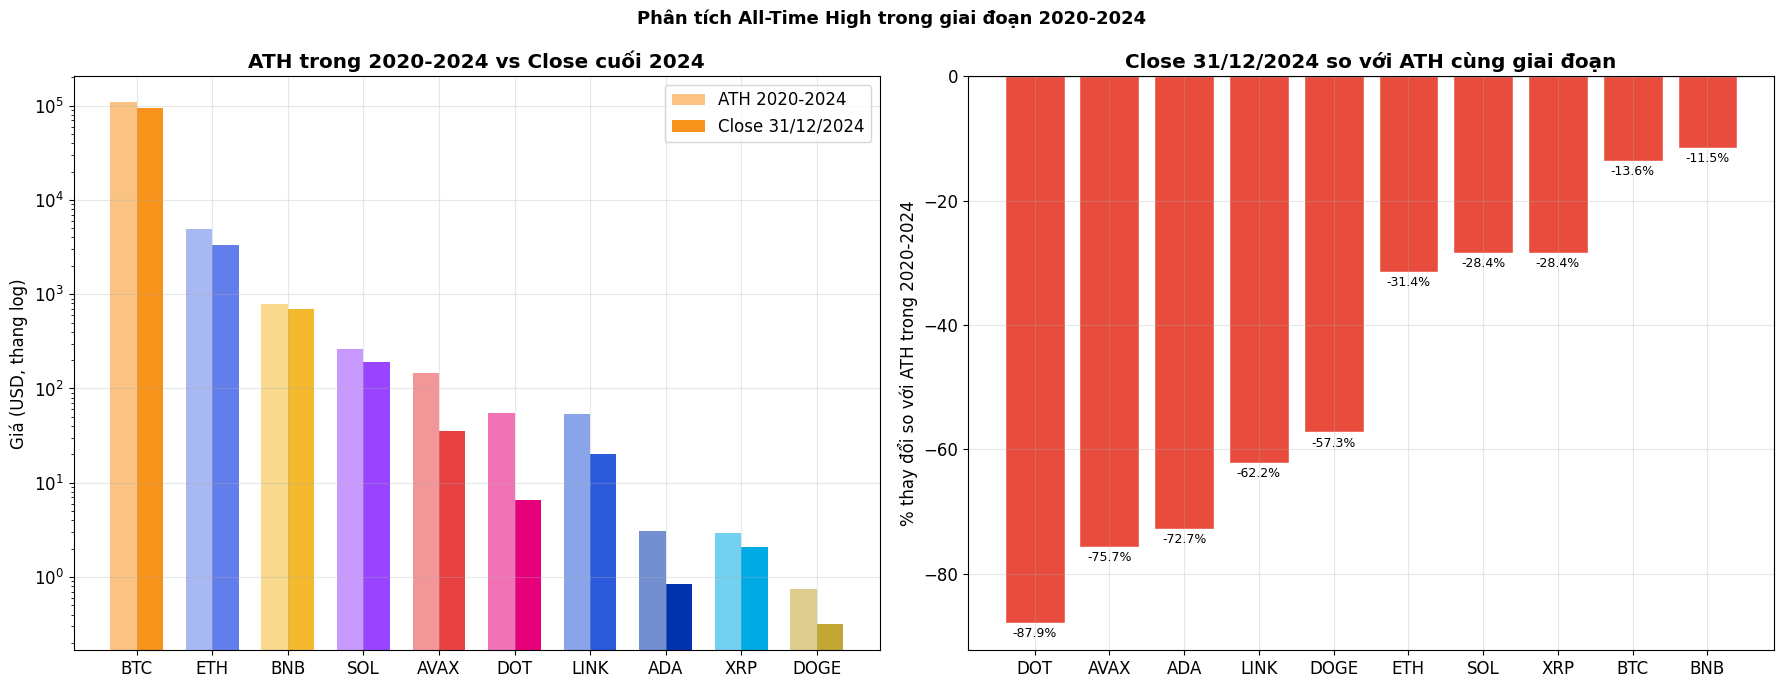

In [23]:
# 8.3 Phân tích ATH trong đúng giai đoạn 2020-2024
# Mục tiêu: tìm đỉnh giá cao nhất của từng coin trong phạm vi nghiên cứu.
ath_records = []

for coin in df_high_clean.columns:
    # high_series dùng để tìm ATH; close_series dùng để lấy giá cuối năm 2024.
    high_series = df_high_clean[coin].dropna().loc[analysis_start:analysis_end]
    close_series = df_close_clean[coin].dropna().loc[analysis_start:analysis_end]
    if high_series.empty or close_series.empty:
        continue

    # idxmax trả về ngày đạt giá high cao nhất trong giai đoạn.
    ath_date = high_series.idxmax()
    ath_usd = high_series.loc[ath_date]
    close_2024 = close_series.loc[close_series.index.max()]

    # Tính khoảng cách từ giá đóng cửa cuối 2024 tới ATH.
    drop_from_ath_2024_pct = (close_2024 - ath_usd) / ath_usd * 100
    ath_records.append({
        "symbol": coin,
        "ath_2020_2024_usd": ath_usd,
        "ath_date": ath_date,
        "close_2024_usd": close_2024,
        "drop_from_ath_2024_pct": drop_from_ath_2024_pct,
    })

df_ath_period = pd.DataFrame(ath_records).sort_values("drop_from_ath_2024_pct")
df_ath_period["ath_date"] = pd.to_datetime(df_ath_period["ath_date"])

print("ATH tính trong giai đoạn 2020-2024:")
print(
    df_ath_period.assign(
        ath_date=df_ath_period["ath_date"].dt.date,
        ath_2020_2024_usd=df_ath_period["ath_2020_2024_usd"].round(4),
        close_2024_usd=df_ath_period["close_2024_usd"].round(4),
        drop_from_ath_2024_pct=df_ath_period["drop_from_ath_2024_pct"].round(1),
    ).to_string(index=False)
)

# Biểu đồ trái so sánh ATH với giá cuối 2024; biểu đồ phải thể hiện khoảng cách % tới ATH.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_df = df_ath_period.sort_values("ath_2020_2024_usd", ascending=False)
x_pos = np.arange(len(plot_df))
width = 0.35
colors_bar = [COIN_COLORS.get(s, "#999") for s in plot_df["symbol"]]

axes[0].bar(x_pos - width/2, plot_df["ath_2020_2024_usd"], width, label="ATH 2020-2024", color=colors_bar, alpha=0.55)
axes[0].bar(x_pos + width/2, plot_df["close_2024_usd"], width, label="Close 31/12/2024", color=colors_bar, alpha=1.0)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(plot_df["symbol"])
axes[0].set_yscale("log")
axes[0].set_ylabel("Giá (USD, thang log)")
axes[0].set_title("ATH trong 2020-2024 vs Close cuối 2024", fontweight="bold")
axes[0].legend()

plot_drop = df_ath_period.sort_values("drop_from_ath_2024_pct")
drop_colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in plot_drop["drop_from_ath_2024_pct"]]
bars_drop = axes[1].bar(plot_drop["symbol"], plot_drop["drop_from_ath_2024_pct"], color=drop_colors, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].bar_label(bars_drop, fmt="%.1f%%", padding=3, fontsize=9)
axes[1].set_ylabel("% thay đổi so với ATH trong 2020-2024")
axes[1].set_title("Close 31/12/2024 so với ATH cùng giai đoạn", fontweight="bold")

plt.suptitle("Phân tích All-Time High trong giai đoạn 2020-2024", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Ý nghĩa phân tích:** ATH trong giai đoạn 2020-2024 cho biết mức giá cao nhất mà từng coin đạt được trong phạm vi nghiên cứu. So sánh với giá đóng cửa cuối 2024 giúp đánh giá mức độ phục hồi hoặc khoảng cách so với đỉnh.

**Quyết định hỗ trợ:** Coin còn cách ATH rất xa có thể là cơ hội hồi phục nhưng cũng có thể phản ánh suy yếu dài hạn, nên không nên mua chỉ vì giá đã giảm sâu. Coin giữ được khoảng cách gần ATH hơn có thể cho thấy sức mạnh tương đối tốt hơn, nhưng vẫn cần kiểm tra xu hướng và volatility trước khi quyết định.


## 9. Kết luận & Insight <a id='sec9'></a>

Phần này tổng hợp các kết quả định lượng chính để trả lời các câu hỏi phân tích ban đầu.

**Giải thích thuật ngữ:**
- **Insight** là nhận định rút ra từ dữ liệu, không chỉ là mô tả biểu đồ. Ví dụ: coin A tăng mạnh nhưng volatility cũng cao, nên lợi nhuận đi kèm rủi ro lớn.
- **Quyết định hỗ trợ** là cách chuyển kết quả phân tích thành hành động: mua, bán, giữ, giảm tỉ trọng, tăng quản trị rủi ro hoặc tiếp tục theo dõi.
- **Tín hiệu giao dịch độc lập:** các kết quả bên dưới dựa trên dữ liệu lịch sử và không nên dùng riêng lẻ để ra quyết định thực tế nếu thiếu bối cảnh thị trường hiện tại.

**Ý nghĩa:** phần kết luận nối kết các kết quả trước đó thành nhận định có thể hành động, thay vì chỉ dừng ở việc tạo biểu đồ.


In [24]:
print("=" * 65)
print("TỔNG HỢP KẾT QUẢ PHÂN TÍCH — 2020-2024")
print("=" * 65)

# 1. Tính tổng tăng trưởng từ ngày đầu có dữ liệu đến cuối giai đoạn.
print("\n1. Tăng trưởng từ ngày đầu có dữ liệu đến 31/12/2024:")
total_returns = {}
for coin in df_close_clean.columns:
    series = df_close_clean[coin].dropna()
    if len(series) >= 2:
        ret = (series.iloc[-1] / series.iloc[0] - 1) * 100
        total_returns[coin] = ret

for coin, ret in sorted(total_returns.items(), key=lambda x: -x[1]):
    sign = "+" if ret > 0 else ""
    bar = "#" * int(min(abs(ret) / 200, 30))
    print(f"  {coin:6s}: {sign}{ret:>10,.1f}%  {bar}")

# 2. Tổng hợp rủi ro biến động bằng độ lệch chuẩn Daily Return.
print("\n2. Volatility — Độ lệch chuẩn Daily Return:")
for coin, v in df_daily_return.std().sort_values(ascending=False).items():
    print(f"  {coin:6s}: {v:.3f}%")

# 3. Xếp hạng mức độ liên hệ của altcoin với BTC bằng Spearman correlation.
print("\n3. Tương quan Spearman với BTC:")
btc_corr = df_return_common.corr(method="spearman")["BTC"].drop("BTC").sort_values(ascending=False)
for coin, c in btc_corr.items():
    print(f"  {coin:6s}: {c:.3f}")

# 4. Diễn giải kết quả thành insight và quyết định hỗ trợ.
print("\n4. Insight chính và quyết định hỗ trợ:")
print("  a. Thị trường crypto có tính tương quan cao; khi BTC yếu, nên thận trọng với quyết định mua altcoin.")
print("  b. SOL, DOT và AVAX có chuỗi dữ liệu ngắn hơn, nên không so sánh tổng lợi nhuận trực tiếp nếu không chuẩn hóa thời gian.")
print("  c. Coin volatility cao cần tỉ trọng nhỏ hơn, stop-loss rộng hơn hoặc chỉ phù hợp với khẩu vị rủi ro cao.")
print("  d. Volume tăng đột biến đi kèm |return| lớn là tín hiệu cần kiểm soát rủi ro trước khi mua/bán.")
print("  e. ATH trong 2020-2024 giúp đánh giá khoảng cách tới đỉnh, nhưng không nên mua chỉ vì giá đã giảm sâu so với ATH.")


TỔNG HỢP KẾT QUẢ PHÂN TÍCH — 2020-2024

1. Tăng trưởng từ ngày đầu có dữ liệu đến 31/12/2024:
  DOGE  : +  15,508.8%  ##############################
  SOL   : +   5,639.3%  ############################
  BNB   : +   5,019.4%  #########################
  ETH   : +   2,452.4%  ############
  ADA   : +   2,424.2%  ############
  BTC   : +   1,199.5%  #####
  LINK  : +   1,004.9%  #####
  XRP   : +     979.3%  ####
  AVAX  : +     571.3%  ##
  DOT   : +     114.3%  

2. Volatility — Độ lệch chuẩn Daily Return:
  DOGE  : 11.486%
  SOL   : 6.593%
  AVAX  : 6.575%
  XRP   : 5.788%
  LINK  : 5.763%
  DOT   : 5.669%
  ADA   : 5.277%
  BNB   : 4.791%
  ETH   : 4.415%
  BTC   : 3.405%

3. Tương quan Spearman với BTC:
  ETH   : 0.806
  DOT   : 0.707
  BNB   : 0.695
  ADA   : 0.688
  DOGE  : 0.672
  LINK  : 0.671
  XRP   : 0.639
  AVAX  : 0.634
  SOL   : 0.601

4. Insight chính và quyết định hỗ trợ:
  a. Thị trường crypto có tính tương quan cao; khi BTC yếu, nên thận trọng với quyết định mua altcoi

---

## Tài liệu tham khảo
- [Binance API Documentation](https://python-binance.readthedocs.io/)
- [Python-Binance Library](https://github.com/sammchardy/python-binance)

---

## Giới hạn phân tích

| Điểm | Ghi chú |
|---|---|
| Dữ liệu giá | OHLCV từ Binance, giai đoạn 01/01/2020 - 31/12/2024 |
| Coin niêm yết muộn | SOL/DOT/AVAX chỉ có dữ liệu từ 2020-08/09, nên khi so sánh tổng lợi nhuận cần nêu rõ độ dài chuỗi khác nhau |
| Correlation | Dùng khoảng thời gian chung từ coin niêm yết muộn nhất để đảm bảo tất cả coin đều có dữ liệu |
| Volume-Return | Dùng Spearman vì volume thường lệch phải và có nhiều giá trị đột biến |
| ATH | ATH được tính từ df_high_clean trong đúng giai đoạn 2020-2024 |
| Quyết định hỗ trợ | Các nhận định mua/bán/giữ là kết quả tham khảo từ dữ liệu lịch sử, cần kết hợp thêm bối cảnh thị trường nếu áp dụng thực tế |
